# Trump on Reddit: exploratory data analysis

**Homework #3.** The dataset is every Reddit submission and comment that mentions "Trump" in six political subreddits, collected in Homework #2 and cleaned in `notebooks/preprocessing/reddit_cleaning.ipynb`.

**Project idea.** We want to follow how comments that support Trump's politics and comments that oppose them change over time, and to compare his first term (2017–2018) with his second term (2025–2026).

## 1. Basic data exploration

This section describes the dataset before any modelling: what it contains, how complete it is, and how records spread over time, communities, authors and threads. Sentiment and topics come in later sections.

Every comparison uses the same four windows, so the two terms are compared at the same point of the presidency:

| Window | Months | Meaning |
|---|---|---|
| `T1_Y1` | Jan–Jun 2017 | first term, first year |
| `T1_Y2` | Jan–Jun 2018 | first term, second year |
| `T2_Y1` | Jan–Jun 2025 | second term, first year |
| `T2_Y2` | Jan–Jun 2026 | second term, second year |


Two limits apply to everything below:

- The data is already filtered to records that mention Trump. We do not have the unfiltered totals, so the charts show volume and composition inside this dataset, not Trump's share of all Reddit discussion.
- r/politics holds about 90% of the comments. Pooled numbers mostly describe r/politics, so the charts also show each subreddit separately.

### 1.1 Setup and loading

In [1]:
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.compute as pc
import pyarrow.parquet as pq
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, PercentFormatter

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 130)

ROOT = Path.cwd()

while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if not (ROOT / "data").exists():
    raise FileNotFoundError("Could not find project root with data/ directory.")

CLEAN = ROOT / "data" / "cleaned"
SUBMISSIONS_PATH = CLEAN / "submissions_clean.parquet"
COMMENTS_PATH = CLEAN / "comments_clean.parquet"

In [2]:
PERIODS = ["T1_Y1", "T1_Y2", "T2_Y1", "T2_Y2"]
PERIOD_YEAR = {"T1_Y1": 2017, "T1_Y2": 2018, "T2_Y1": 2025, "T2_Y2": 2026}
PERIOD_SHORT = {p: f"{y}\n{p[:2]}, year {p[-1]}" for p, y in PERIOD_YEAR.items()}
PERIOD_LONG = {p: f"Jan–Jun {y} ({'first' if p[:2] == 'T1' else 'second'} term, year {p[-1]})" for p, y in PERIOD_YEAR.items()}
PERIOD_LINESTYLE = {"T1_Y1": "-", "T1_Y2": "--", "T2_Y1": "-", "T2_Y2": "--"}
TERMS = ["T1", "T2"]
TERM_LABEL = {"T1": "First term (2017–2018)", "T2": "Second term (2025–2026)"}
MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
WEEKDAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
ET = "America/New_York"

# subreddits ordered by number of comments
SUBREDDITS = ["politics", "AskTrumpSupporters", "Conservative", "PoliticalDiscussion", "democrats", "Republican"]
STANCES = ["supporter", "undecided", "nonsupporter"]

# colours: one meaning per colour in the whole notebook
TERM_COLOR = {"T1": "#2a78d6", "T2": "#eb6834"}
PERIOD_COLOR = {p: TERM_COLOR[p[:2]] for p in PERIODS}
SUB_COLOR = dict(zip(SUBREDDITS, ["#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]))
STANCE_COLOR = {"supporter": "#e34948", "undecided": "#b9b8b1", "nonsupporter": "#2a78d6"}
NEUTRAL = "#6b6a66"
INK, INK_2, MUTED, GRID, AXIS = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUES = mcolors.LinearSegmentedColormap.from_list("blues", ["#eef5fe", "#b7d3f6", "#6da7ec", "#2a78d6", "#184f95", "#0d366b"])

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 10, "text.color": INK,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.titlesize": 10, "axes.titleweight": "normal", "axes.titlelocation": "left", "axes.titlecolor": INK_2,
    "axes.labelsize": 9.5, "axes.labelcolor": INK_2,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9, "lines.linewidth": 2,
})


def compact(x, _=None):
    """Tick label: 1500 -> 1.5K, 2000000 -> 2M."""
    if abs(x) >= 1e6:
        return f"{x / 1e6:g}M"
    if abs(x) >= 1e3:
        return f"{x / 1e3:g}K"
    return f"{x:g}"


COMPACT = FuncFormatter(compact)
PERCENT = FuncFormatter(lambda x, _: f"{x:g}%")


def headline(fig, text):
    fig.suptitle(text, x=0.01, ha="left", fontsize=12.5, fontweight="bold", color=INK)


def term_handles(marker=None):
    if marker:
        return [Line2D([], [], color=TERM_COLOR[t], marker=marker, linestyle="", markersize=8, label=TERM_LABEL[t]) for t in TERMS]
    return [Patch(color=TERM_COLOR[t], label=TERM_LABEL[t]) for t in TERMS]


def ink_on(fill):
    """Black or white text, whichever reads better on the given fill colour."""
    r, g, b = mcolors.to_rgb(fill)
    return INK if 0.2126 * r + 0.7152 * g + 0.0722 * b > 0.55 else "white"


def with_commas(df):
    """Integer columns as strings with thousands separators (for display only)."""
    return df.apply(lambda s: s.map("{:,}".format) if pd.api.types.is_integer_dtype(s) else s)

The comments file is 2 GB on disk and its two text columns would need about 7 GB of RAM. So the comments are loaded without `body` and `body_clean`. The only thing this section needs from the text is its length, and that is computed inside Arrow, one row group at a time.

In [3]:
subs = pd.read_parquet(SUBMISSIONS_PATH)

comments_file = pq.ParquetFile(COMMENTS_PATH)
TEXT_COLUMNS = ["body", "body_clean"]
light_columns = [c for c in comments_file.schema_arrow.names if c not in TEXT_COLUMNS]
com = pd.read_parquet(COMMENTS_PATH, columns=light_columns)

n_words, n_chars = [], []
for i in range(comments_file.metadata.num_row_groups):
    body = comments_file.read_row_group(i, columns=["body_clean"])["body_clean"]
    n_words.append(pc.count_substring_regex(body, r"\S+").to_numpy())
    n_chars.append(pc.utf8_length(body).to_numpy())

assert sum(len(a) for a in n_words) == len(com)
com["n_words"] = np.concatenate(n_words).astype("int32")
com["n_chars"] = np.concatenate(n_chars).astype("int32")
del n_words, n_chars, body

# US Eastern time for everything about days and hours: the audience and the events are mostly American
for df in (subs, com):
    local = df["created_at"].dt.tz_convert(ET).dt.tz_localize(None)
    df["date_et"] = local.dt.normalize()
    df["hour_et"] = local.dt.hour.astype("int8")
    df["weekday_et"] = local.dt.dayofweek.astype("int8")
del local

print(f"submissions: {subs.shape[0]:,} rows x {subs.shape[1]} columns, {subs.memory_usage(deep=True).sum() / 1024**3:.2f} GB in memory")
print(f"comments:    {com.shape[0]:,} rows x {com.shape[1]} columns, {com.memory_usage(deep=True).sum() / 1024**3:.2f} GB in memory")

submissions: 497,211 rows x 35 columns, 0.30 GB in memory
comments:    4,514,780 rows x 25 columns, 0.79 GB in memory


### 1.2 What is in the dataset

**Question:** how many records do we have, from when, and what does one record look like?

In [4]:
def overview(df, path, thread_column):
    meta = pq.ParquetFile(path).metadata
    return {
        "rows": f"{meta.num_rows:,}",
        "columns in the file": meta.num_columns,
        "file size": f"{path.stat().st_size / 1024**2:,.0f} MB",
        "first record (UTC)": f"{df['created_at'].min():%Y-%m-%d %H:%M}",
        "last record (UTC)": f"{df['created_at'].max():%Y-%m-%d %H:%M}",
        "subreddits": df["subreddit"].nunique(),
        "unique authors (without [deleted])": f"{df.loc[~df['author_deleted'], 'author'].nunique():,}",
        "unique threads": f"{df[thread_column].nunique():,}",
    }


pd.DataFrame({
    "submissions": overview(subs, SUBMISSIONS_PATH, "id"),
    "comments": overview(com, COMMENTS_PATH, "submission_id"),
})

,submissions,comments
rows,"497,211","4,514,780"
columns in the file,32,22
file size,125 MB,"2,045 MB"
first record (UTC),2017-01-01 00:03,2017-01-01 00:00
last record (UTC),2026-06-30 23:59,2026-06-30 23:58
subreddits,6,6
unique authors (without [deleted]),"76,890","482,468"
unique threads,"497,211","325,714"


In [5]:
named = com.loc[~com["author_deleted"]]          # comments whose author is known

by_period = pd.DataFrame({
    "submissions": subs.groupby("period").size(),
    "comments": com.groupby("period").size(),
    "comment authors": named.groupby("period")["author"].nunique(),
    "threads with comments": com.groupby("period")["submission_id"].nunique(),
})
by_period["comments per author"] = (by_period["comments"] / by_period["comment authors"]).round(1)
by_period["comments per thread"] = (by_period["comments"] / by_period["threads with comments"]).round(1)
by_period.index = [PERIOD_LONG[p] for p in by_period.index]
with_commas(by_period)

,submissions,comments,comment authors,threads with comments,comments per author,comments per thread
"Jan–Jun 2017 (first term, year 1)","192,036","1,723,090","166,876","118,704",10.3,14.5
"Jan–Jun 2018 (first term, year 2)","150,335","1,366,732","144,335","101,016",9.5,13.5
"Jan–Jun 2025 (second term, year 1)","94,650","854,162","180,079","61,230",4.7,14.0
"Jan–Jun 2026 (second term, year 2)","60,190","570,796","120,876","44,858",4.7,12.7


The columns fall into five groups. Both tables share the same idea, so they are described together.

| Group | Submissions | Comments |
|---|---|---|
| Identity and links | `id` | `id`, `submission_id` (the thread), `parent_id` (what it replies to), `is_top_level` |
| When and where | `created_utc`, `created_at`, `source_month`, `year`, `period`, `term`, `subreddit` | the same |
| Who | `author`, `author_deleted`, `author_flair_text`, `stance` | the same |
| What | `title`, `selftext`, `text`, `text_clean`, `is_self`, `domain`, `url`, `link_flair_text` | `body`, `body_clean` |
| Reception | `score`, `num_comments`, `upvote_ratio` | `score`, `controversiality` |
| Cleaning flags | `selftext_deleted`, `selftext_removed`, `title_unusable`, `is_mod_or_bot_post`, `submission_mentions_trump`, `has_trump_comment`, `in_scope`, `removed_by_category`, `stickied` | `trump_only_in_quote`, `edited`, `stickied` |

`stance` is the self-declared position of the author (supporter, nonsupporter, undecided). It exists only in r/AskTrumpSupporters, where the flair is mandatory. It is the only direct support/oppose label in the dataset.

In [6]:
# one comment from each window (authors are left out on purpose)
sample_columns = ["created_at", "subreddit", "period", "stance", "score", "controversiality", "is_top_level", "body_clean"]
sample = pd.concat(
    [comments_file.read_row_group(i, columns=sample_columns).slice(500, 1).to_pandas() for i in (0, 9, 16, 22)],
    ignore_index=True,
)
sample["created_at"] = sample["created_at"].dt.strftime("%Y-%m-%d %H:%M")
sample["body_clean"] = sample["body_clean"].str.replace("\n", " ").str.slice(0, 120) + "…"
sample

,created_at,subreddit,period,stance,score,controversiality,is_top_level,body_clean
0,2017-01-01 01:35,PoliticalDiscussion,T1_Y1,<NA>,2,0,False,"True. However, I thought it was a pretty accurate characterization of stuff Trump says.…"
1,2018-01-07 02:30,politics,T1_Y2,<NA>,94,0,False,It’s been renamed the Trump-Fox effect.…
2,2025-01-15 02:51,politics,T2_Y1,<NA>,3,0,True,“I am nominating Eleon to lead the SEC.” -Trump tomorrow…
3,2026-04-18 11:45,politics,T2_Y2,<NA>,1,0,False,"""Trump will do bad things"" \*Loses the election, Trump does bad things\* ""Told you so!"" Wow, incredible stuff. She's nev…"


**What we see.**

- The dataset has 497,211 submissions and 4,514,780 comments, so there are about nine comments for every submission.
- It covers four six-month windows between 1 January 2017 and 30 June 2026, not a continuous period.
- The volume falls from window to window: 1.72M comments in 2017, 1.37M in 2018, 0.85M in 2025 and 0.57M in 2026.
- The number of authors does not fall with it. The 2025 window has the most authors (180,079) but half the comments of 2017. An average author wrote about 10 comments per window in the first term and under 5 in the second.

### 1.3 Data quality

**Questions:** which columns have missing values, and is the loss of content (deleted or removed records) the same in every window?

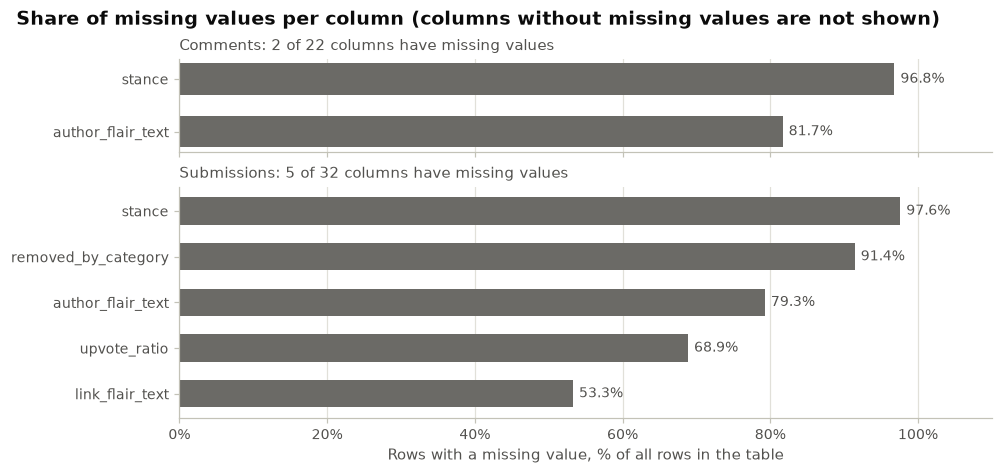

In [7]:
def null_share(path):
    """% of nulls per column, read from the parquet footer where possible (no data is loaded)."""
    f = pq.ParquetFile(path)
    meta = f.metadata
    out = {}
    for j in range(meta.num_columns):
        name = meta.schema.column(j).name
        stats = [meta.row_group(i).column(j).statistics for i in range(meta.num_row_groups)]
        if all(s is not None and s.has_null_count for s in stats):
            out[name] = sum(s.null_count for s in stats)
        else:
            out[name] = f.read(columns=[name])[name].null_count
    return 100 * pd.Series(out) / meta.num_rows


nulls = {"Comments": null_share(COMMENTS_PATH), "Submissions": null_share(SUBMISSIONS_PATH)}
with_nulls = {k: s[s > 0].sort_values() for k, s in nulls.items()}

fig, axes = plt.subplots(2, 1, figsize=(9, 4.2), sharex=True, layout="constrained",
                         gridspec_kw={"height_ratios": [len(s) for s in with_nulls.values()]})
for ax, (name, s) in zip(axes, with_nulls.items()):
    bars = ax.barh(s.index, s.values, height=0.6, color=NEUTRAL)
    ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9, color=INK_2)
    ax.set_title(f"{name}: {len(s)} of {len(nulls[name])} columns have missing values")
    ax.grid(axis="y", visible=False)
axes[-1].set_xlim(0, 110)
axes[-1].set_xticks(range(0, 101, 20))
axes[-1].xaxis.set_major_formatter(PERCENT)
axes[-1].set_xlabel("Rows with a missing value, % of all rows in the table")
headline(fig, "Share of missing values per column (columns without missing values are not shown)")
plt.show()

**What we see.** Missing values appear only in optional metadata, and each gap has a structural reason:

- `stance` is empty outside r/AskTrumpSupporters, which is 3% of the data.
- `author_flair_text` is empty because most users in the other subreddits do not set a flair.
- `upvote_ratio` and `removed_by_category` are empty for every first-term submission. These fields exist only in the 2025–2026 archive. The 68.9% matches the first term's share of submissions exactly.
- `link_flair_text` is a label that moderators add to some posts only.

The fields we rely on (ids, time, subreddit, author, text, score) have no missing values. Nothing needs to be imputed, but `upvote_ratio` cannot be compared across terms.

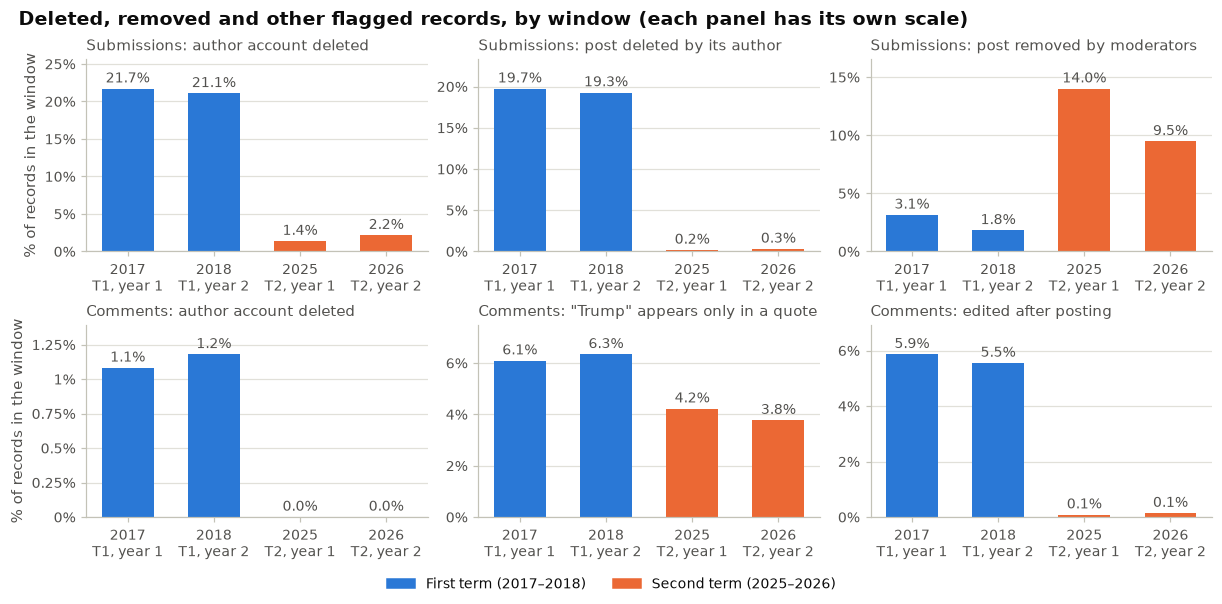

In [8]:
FLAGS = [
    (subs, "author_deleted", "Submissions: author account deleted"),
    (subs, "selftext_deleted", "Submissions: post deleted by its author"),
    (subs, "selftext_removed", "Submissions: post removed by moderators"),
    (com, "author_deleted", "Comments: author account deleted"),
    (com, "trump_only_in_quote", 'Comments: "Trump" appears only in a quote'),
    (com, "edited", "Comments: edited after posting"),
]

fig, axes = plt.subplots(2, 3, figsize=(11, 5.4), layout="constrained")
for ax, (df, column, label) in zip(axes.flat, FLAGS):
    share = 100 * df.groupby("period")[column].mean().astype(float).reindex(PERIODS)
    bars = ax.bar([PERIOD_SHORT[p] for p in PERIODS], share.values, width=0.6, color=[PERIOD_COLOR[p] for p in PERIODS])
    ax.bar_label(bars, fmt="%.1f%%", padding=2, fontsize=9, color=INK_2)
    ax.set_title(label)
    ax.set_ylim(0, share.max() * 1.18)
    ax.yaxis.set_major_formatter(PERCENT)
    ax.grid(axis="x", visible=False)
for ax in axes[:, 0]:
    ax.set_ylabel("% of records in the window")
fig.legend(handles=term_handles(), loc="outside lower center", ncols=2)
headline(fig, "Deleted, removed and other flagged records, by window (each panel has its own scale)")
plt.show()

The flags differ sharply between the terms. The raw files from Homework #2 record when the archive saved each record (`retrieved_on`, plus a second save inside `_meta` for 2025–2026), so the cause can be measured instead of guessed.

In [9]:
RAW_DIR = next((d for d in (ROOT / "data", ROOT / "data" / "processed" / "combined") if (d / "comments_trump.parquet").exists()), None)

if RAW_DIR is None:
    print("Raw files from Homework #2 were not found, so the archive-lag check is skipped.")
else:
    lag = {}
    for name in ["comments", "submissions"]:
        raw = pd.read_parquet(RAW_DIR / f"{name}_trump.parquet", columns=["source_month", "created_utc", "retrieved_on", "_meta"])
        year = raw["source_month"].str[:4].rename("window")
        second_save = pd.to_numeric(raw["_meta"].str.extract(r"retrieved_2nd_on': (\d+)")[0])
        days = pd.DataFrame({
            "first save, days after posting": (raw["retrieved_on"] - raw["created_utc"]) / 86400,
            "second save, days after posting": (second_save - raw["created_utc"]) / 86400,
        })
        lag[name] = days.groupby(year).median()
        if name == "comments":
            edited_in_meta = 100 * raw["_meta"].str.contains("is_edited", na=False).groupby(year).mean()
    del raw, days, second_save
    display(pd.concat(lag, axis=1).round(1))
    print("median values; NaN = the archive made no second save")
    print("raw comments marked as edited inside `_meta`, %:", edited_in_meta.round(1).to_dict())

comments                                                    submissions                                
       first save, days after posting second save, days after posting first save, days after posting second save, days after posting
window                                                                                                                              
2017                             19.7                             NaN                           31.5                             NaN
2018                             26.3                             NaN                           33.5                             NaN
2025                              0.0                             1.5                            0.0                             1.5
2026                              0.0                             1.5                            0.0                             1.5

median values; NaN = the archive made no second save
raw comments marked as edited inside `_meta`, %: {'2017': 0.0, '2018': 0.0, '2025': 12.4, '2026': 10.7}


In [10]:
comment_counts = com.groupby("submission_id").size()

pd.Series({
    "duplicate submission ids": f"{subs['id'].duplicated().sum():,}",
    "duplicate comment ids": f"{com['id'].duplicated().sum():,}",
    "comments whose thread is in the submissions table": f"{100 * com['submission_id'].isin(subs['id']).mean():.2f}%",
    "submissions with at least one comment in the comments table": f"{100 * subs['id'].isin(comment_counts.index).mean():.2f}%",
    "submissions that mention Trump in the title or body": f"{100 * subs['submission_mentions_trump'].mean():.2f}%",
    "submissions posted by a moderator or bot": f"{100 * subs['is_mod_or_bot_post'].mean():.2f}%",
}, name="value").to_frame()

,value
duplicate submission ids,0
duplicate comment ids,0
comments whose thread is in the submissions table,99.80%
submissions with at least one comment in the comments table,65.12%
submissions that mention Trump in the title or body,69.00%
submissions posted by a moderator or bot,0.12%


**What we see.** The two terms were archived in different ways, and this is visible in the flags.

- In the first term about 21% of submissions come from deleted accounts and about 19% were deleted by their authors. In the second term both are close to zero.
- Comments show the same break: 5.5–5.9% are marked as edited in the first term and 0.1% in the second; deleted comment authors go from 1.1% to 0.0%.
- People did not stop editing and deleting. The archive changed. First-term comments were saved a median of 20–26 days after posting and submissions 32–34 days after. Second-term records were saved at the moment of posting and refreshed once, 1.5 days later. Deletions that happen after 1.5 days are therefore invisible in the second term.
- The `edited` column is not comparable at all. The newer archive stores edits inside `_meta`, where 11–12% of second-term comments are marked as edited. The cleaning step did not carry this over, so the 0.1% is a gap in our flag, not a change in behaviour.
- Moderator removals go the other way, 2–3% in the first term and 10–14% in the second. This may reflect stricter moderation or only better recording of removals.
- Comments that mention Trump only inside a quote are 6% in the first term and 4% in the second. Sentiment analysis must exclude them, because the words belong to someone else.

The integrity checks are clean: no duplicate ids, and 99.8% of comments have their thread in the submissions table. Only 65% of submissions have a comment in the comments table; the rest are in the dataset because their own title or body mentions Trump.

**What it means for the project.** Text is lost more often in the first term (deleted posts). Scores were recorded three to five weeks after posting in the first term and 1.5 days after in the second. Differences between terms in these fields can be artefacts, so they need care before we read them as changes in attitude.

### 1.4 Volume over time

**Questions:** how many records are there per month, does the second term repeat the rhythm of the first, and which days stand out?

The four windows are not adjacent, so they are never joined with one line. Each window gets its own block or panel.

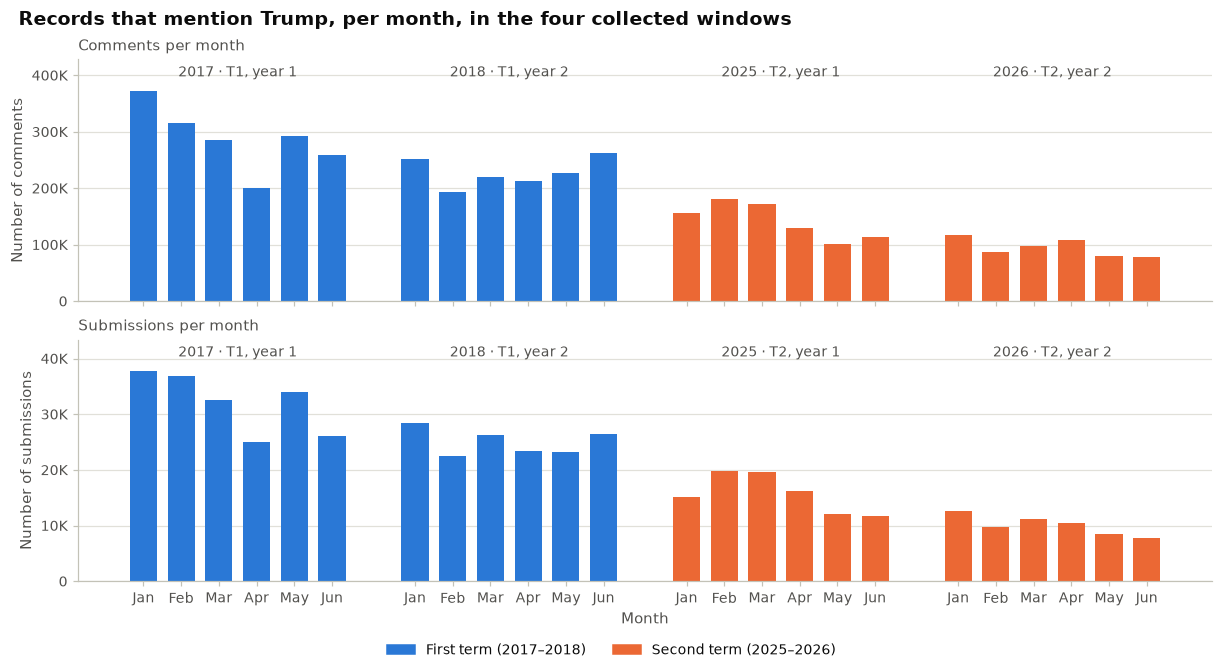

In [11]:
monthly = pd.DataFrame({
    "comments": com.groupby("source_month").size(),
    "submissions": subs.groupby("source_month").size(),
}).sort_index()
months = list(monthly.index)
x = np.array([i + (i // 6) * 1.2 for i in range(len(months))])       # a gap between windows
bar_colors = [TERM_COLOR["T1"] if m < "2020" else TERM_COLOR["T2"] for m in months]

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, layout="constrained")
for ax, kind in zip(axes, ["comments", "submissions"]):
    ax.bar(x, monthly[kind].values, width=0.72, color=bar_colors)
    ax.set_title(f"{kind.capitalize()} per month")
    ax.set_ylabel(f"Number of {kind}")
    ax.yaxis.set_major_formatter(COMPACT)
    ax.grid(axis="x", visible=False)
    top = monthly[kind].max()
    ax.set_ylim(0, top * 1.15)
    for w, p in enumerate(PERIODS):
        ax.text(x[w * 6:(w + 1) * 6].mean(), top * 1.07, PERIOD_SHORT[p].replace("\n", " · "), ha="center", fontsize=9, color=INK_2)
axes[-1].set_xticks(x, MONTH_NAMES * 4)
axes[-1].set_xlabel("Month")
fig.legend(handles=term_handles(), loc="outside lower center", ncols=2)
headline(fig, "Records that mention Trump, per month, in the four collected windows")
plt.show()

**What we see.**

- Every month of the second term has fewer records than any month of the first term. Comments go from 372K in January 2017 to 79K in June 2026.
- Submissions follow the same path, from 38K to 8K per month.
- The fall is steady rather than sudden, and it continues inside the second term.

**Caution.** The data holds only records that mention Trump, and we do not have the unfiltered totals. A lower count can mean less talk about Trump, less activity on these subreddits in general, more removed content, or a less complete archive. The counts alone cannot separate these explanations, so later sections compare shares, not raw counts.

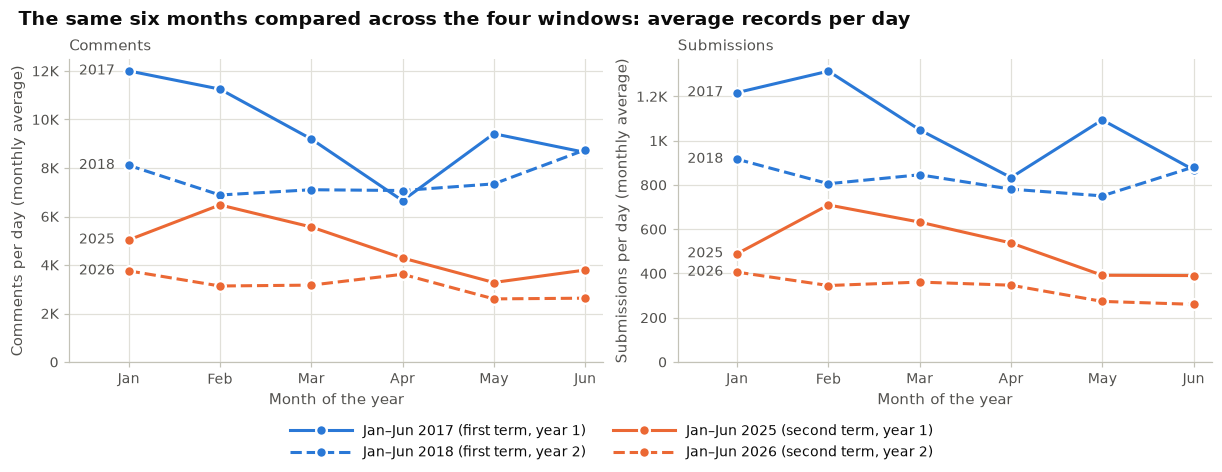

month,Jan,Feb,Mar,Apr,May,Jun
window,,,,,,
2017 comments per day,"12,004","11,252","9,196","6,655","9,414","8,644"
2018 comments per day,"8,110","6,886","7,104","7,072","7,345","8,748"
2025 comments per day,"5,035","6,477","5,568","4,289","3,279","3,793"
2026 comments per day,"3,759","3,135","3,171","3,618","2,603","2,632"


In [12]:
per_day = monthly.div(pd.PeriodIndex(months, freq="M").days_in_month.to_numpy(), axis=0)   # removes the short-February effect

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), layout="constrained")
for ax, kind in zip(axes, ["comments", "submissions"]):
    for p in PERIODS:
        y = per_day.loc[[m for m in months if m.startswith(str(PERIOD_YEAR[p]))], kind].to_numpy()
        ax.plot(range(6), y, color=PERIOD_COLOR[p], linestyle=PERIOD_LINESTYLE[p], marker="o", markersize=7,
                markeredgecolor="white", markeredgewidth=1.5, label=PERIOD_LONG[p])
        ax.annotate(str(PERIOD_YEAR[p]), (0, y[0]), xytext=(-9, 0), textcoords="offset points", ha="right", va="center", fontsize=9, color=INK_2)
    ax.set_xticks(range(6), MONTH_NAMES)
    ax.set_xlim(-0.65, 5.2)
    ax.set_ylim(0, None)
    ax.yaxis.set_major_formatter(COMPACT)
    ax.set_xlabel("Month of the year")
    ax.set_ylabel(f"{kind.capitalize()} per day (monthly average)")
    ax.set_title(kind.capitalize())
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=2, handlelength=4.5)
headline(fig, "The same six months compared across the four windows: average records per day")
plt.show()

comments_per_day = per_day["comments"].round(0).astype(int).to_frame()
comments_per_day["window"] = [f"{m[:4]} comments per day" for m in months]
comments_per_day["month"] = MONTH_NAMES * 4
with_commas(comments_per_day.pivot(index="window", columns="month", values="comments")[MONTH_NAMES])

**What we see.**

- The first year of each term starts high and then decays. In 2017 the daily average falls from 12.0K comments in January to 6.6K in April. In 2025 it peaks in February at 6.5K and falls to 3.3K by May.
- The second year of each term is flat: 6.9K–8.7K per day in 2018 and 2.6K–3.8K in 2026.
- 2017 has a second wave in May (9.4K per day), which the daily chart below ties to the firing of FBI director Comey and the events that followed.

The shape "strong start, then decay" repeats in both terms. That makes year 1 against year 1 and year 2 against year 2 the fair comparisons, which is how the windows were designed.

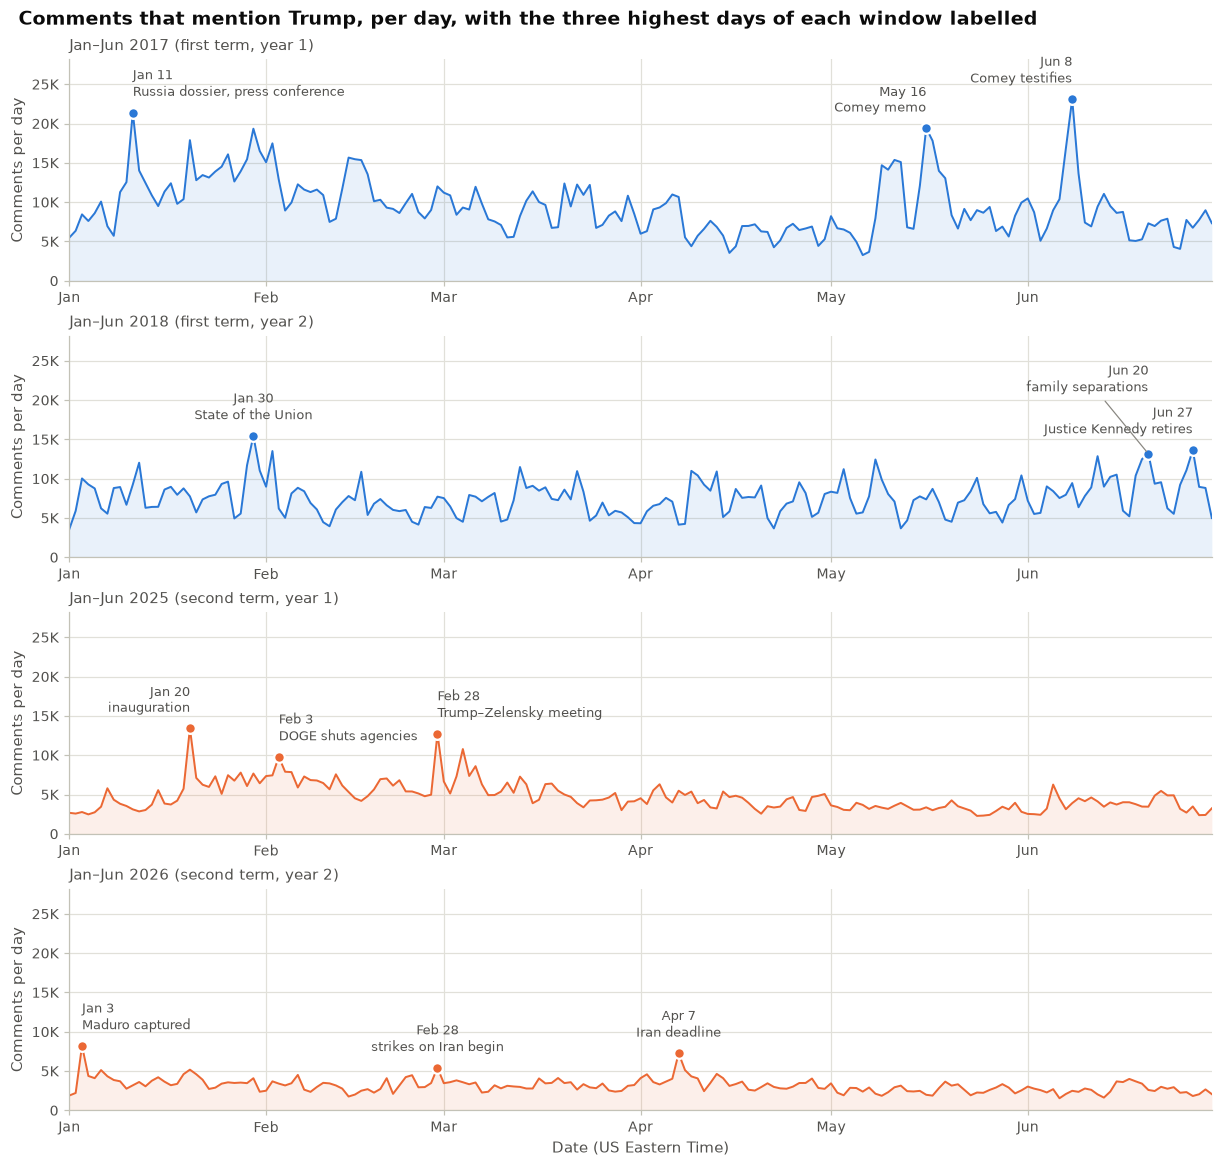

inauguration day 2017-01-20: 17,885 comments, day number 5 of 181 in its window
inauguration day 2025-01-20: 13,413 comments, day number 1 of 181 in its window


,window,date,weekday,comments,times the window median,event
0,T1_Y1,2017-01-11,Wed,21404,2.4,"Russia dossier, press conference"
1,T1_Y1,2017-05-16,Tue,19408,2.2,Comey memo
2,T1_Y1,2017-06-08,Thu,23103,2.6,Comey testifies
3,T1_Y2,2018-01-30,Tue,15451,2.1,State of the Union
4,T1_Y2,2018-06-20,Wed,13172,1.8,family separations
5,T1_Y2,2018-06-27,Wed,13654,1.8,Justice Kennedy retires
6,T2_Y1,2025-01-20,Mon,13413,3.1,inauguration
7,T2_Y1,2025-02-03,Mon,9787,2.3,DOGE shuts agencies
8,T2_Y1,2025-02-28,Fri,12747,3.0,Trump–Zelensky meeting
9,T2_Y2,2026-01-03,Sat,8205,2.7,Maduro captured


In [13]:
# Known events, used to label the peaks found below. Dates are US Eastern.
# Value: (short name, text alignment). "left" starts the text at the peak, "right" ends it there.
EVENTS = {
    "2017-01-11": ("Russia dossier, press conference", "left"),
    "2017-05-16": ("Comey memo", "right"),
    "2017-06-08": ("Comey testifies", "right"),
    "2018-01-30": ("State of the Union", "center"),
    "2018-06-20": ("family separations", "right"),
    "2018-06-27": ("Justice Kennedy retires", "right"),
    "2025-01-20": ("inauguration", "right"),
    "2025-02-03": ("DOGE shuts agencies", "left"),
    "2025-02-28": ("Trump–Zelensky meeting", "left"),
    "2026-01-03": ("Maduro captured", "left"),
    "2026-02-28": ("strikes on Iran begin", "center"),
    "2026-04-07": ("Iran deadline", "center"),
}


def top_peaks(series, n=3, min_gap_days=7):
    """The n highest days that are at least min_gap_days apart."""
    picked = []
    for day in series.sort_values(ascending=False).index:
        if all(abs((day - other).days) >= min_gap_days for other in picked):
            picked.append(day)
        if len(picked) == n:
            break
    return picked


daily = com.groupby(["period", "date_et"]).size()
peak_rows = []
window_days = {}

fig, axes = plt.subplots(4, 1, figsize=(11, 10.5), sharey=True, layout="constrained")
for ax, p in zip(axes, PERIODS):
    year = PERIOD_YEAR[p]
    s = daily[p].reindex(pd.date_range(f"{year}-01-01", f"{year}-06-30"), fill_value=0)
    window_days[p] = s
    ax.plot(s.index, s.values, color=PERIOD_COLOR[p], linewidth=1.3)
    ax.fill_between(s.index, s.values, color=PERIOD_COLOR[p], alpha=0.10, linewidth=0)
    labelled = []
    for day in top_peaks(s):
        key = f"{day:%Y-%m-%d}"
        name, align = EVENTS.get(key, ("", "center"))
        label = f"{day:%b} {day.day}" + (f"\n{name}" if name else "")
        raised = any(abs((day - other).days) <= 12 for other in labelled)      # a neighbouring label is in the way
        ax.plot([day], [s[day]], marker="o", markersize=7, color=PERIOD_COLOR[p], markeredgecolor="white", markeredgewidth=1.5)
        ax.annotate(label, (day, s[day]), xytext=(0, 38 if raised else 8), textcoords="offset points", ha=align, va="bottom",
                    fontsize=8.5, color=INK_2, arrowprops={"arrowstyle": "-", "color": MUTED, "linewidth": 0.8} if raised else None)
        labelled.append(day)
        peak_rows.append({"window": p, "date": key, "weekday": f"{day:%a}", "comments": int(s[day]),
                          "times the window median": round(s[day] / s.median(), 1), "event": name})
    ax.set_title(PERIOD_LONG[p])
    ax.set_ylabel("Comments per day")
    ax.set_xlim(s.index[0], s.index[-1])
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.yaxis.set_major_formatter(COMPACT)
axes[0].set_ylim(0, daily.max() * 1.22)
axes[-1].set_xlabel("Date (US Eastern Time)")
headline(fig, "Comments that mention Trump, per day, with the three highest days of each window labelled")
plt.show()

for p, day in {"T1_Y1": pd.Timestamp("2017-01-20"), "T2_Y1": pd.Timestamp("2025-01-20")}.items():
    s = window_days[p]
    print(f"inauguration day {day:%Y-%m-%d}: {s[day]:,} comments, day number {int(s.rank(ascending=False)[day])} of {len(s)} in its window")

peaks = pd.DataFrame(peak_rows).sort_values("date", ignore_index=True)
peaks

The event names are not guessed from the date alone. The table below shows, for each labelled day, the two threads that collected the most comments mentioning Trump on that day. It uses the same comment-to-submission link as section 1.7.

In [14]:
on_peak_days = com.loc[com["date_et"].isin(pd.to_datetime(peaks["date"])), ["date_et", "submission_id"]]
busiest = (
    on_peak_days.groupby(["date_et", "submission_id"]).size().rename("comments that day").reset_index()
    .sort_values(["date_et", "comments that day"], ascending=[True, False])
    .groupby("date_et").head(2)
    .merge(subs[["id", "subreddit", "title"]], left_on="submission_id", right_on="id", how="left")
)
busiest["date"] = busiest["date_et"].dt.strftime("%Y-%m-%d")
busiest["title"] = busiest["title"].str.slice(0, 115)
busiest[["date", "subreddit", "comments that day", "title"]]

,date,subreddit,comments that day,title
0,2017-01-11,politics,3920,Megathread: Intelligence report claims Russia has compromising information on Trump
1,2017-01-11,politics,2477,Trump shouted down CNN’s Jim Acosta as ‘fake news’ then took a question from Breitbart.
2,2017-05-16,politics,2495,Comey Memo Says Trump Asked Him to End Flynn Investigation
3,2017-05-16,politics,1662,Megathread: Trump tweets defense of classified information sharing with Russia
4,2017-06-08,politics,9058,Discussion Megathread: James Comey Testifies before Senate Intelligence Committee
5,2017-06-08,politics,1980,Discussion Megathread: James Comey Testified before Senate Intelligence Committee
6,2018-01-30,politics,2429,Discussion Thread: 2018 State of the Union Address
7,2018-01-30,politics,1888,Megathread: Trump Administration Declines to Enact New Russia Sanctions
8,2018-06-20,politics,1424,Donald Trump is indisputably the worst president in American history
9,2018-06-20,politics,458,Trump falsely claimed for days that he couldn’t end family separations


**What we see.**

- Activity is bursty. The highest days reach 1.8 to 3.1 times the median day of their window.
- Every labelled peak matches a news event, confirmed by the busiest threads of that day (table above).
- The themes differ between the terms. First-term peaks are about the Russia investigation and domestic institutions: the dossier, the Comey memo and testimony, the State of the Union, family separations at the border, a Supreme Court vacancy. Second-term peaks are about the inauguration, the DOGE takeover of federal agencies, and foreign policy: the Zelensky meeting, the capture of Maduro, the war with Iran.
- The inauguration is the highest day of 2025. In 2017 it is not among the three highest: 17,885 comments on 20 January against 21,404 on the day of the dossier story nine days earlier.
- Two of the three highest days of 2026 are Saturdays, which is unusual for a dataset that is otherwise quiet at weekends (section 1.10).

**Note on dates.** Days are in US Eastern Time. The windows were cut by UTC month, so 30 June misses its last four hours.

### 1.5 Where: subreddits

**Questions:** which communities are the most active, and does the mix of communities change between the terms?

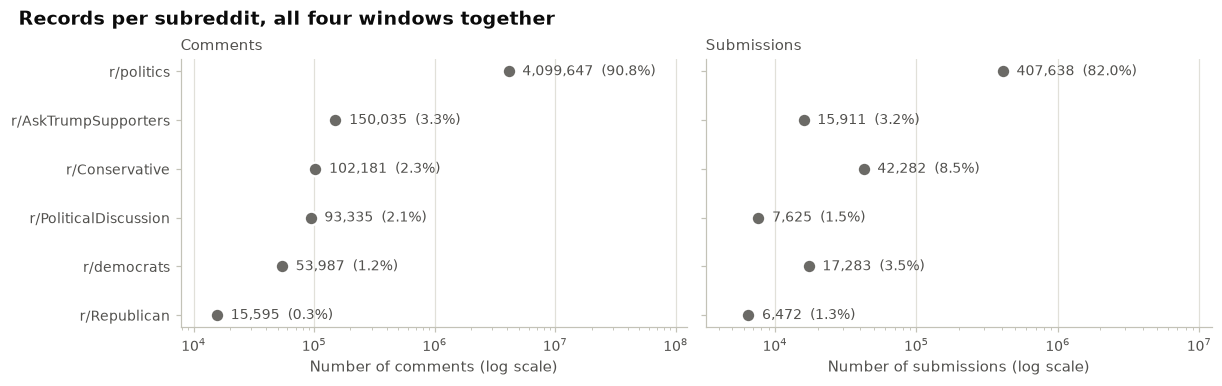

In [15]:
size = pd.DataFrame({
    "comments": com["subreddit"].value_counts(),
    "submissions": subs["subreddit"].value_counts(),
}).reindex(SUBREDDITS)
y_pos = np.arange(len(SUBREDDITS))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True, layout="constrained")
for ax, kind in zip(axes, ["comments", "submissions"]):
    ax.scatter(size[kind], y_pos, s=80, color=NEUTRAL, edgecolor="white", linewidth=1.5, zorder=3)
    for v, yy in zip(size[kind], y_pos):
        ax.annotate(f"{v:,}  ({100 * v / size[kind].sum():.1f}%)", (v, yy), xytext=(9, 0), textcoords="offset points",
                    va="center", fontsize=9, color=INK_2)
    ax.set_xscale("log")
    ax.set_xlim(size[kind].min() / 2, size[kind].max() * 30)
    ax.set_xlabel(f"Number of {kind} (log scale)")
    ax.set_title(kind.capitalize())
    ax.grid(axis="y", visible=False)
axes[0].set_yticks(y_pos, [f"r/{s}" for s in SUBREDDITS])
axes[0].invert_yaxis()
headline(fig, "Records per subreddit, all four windows together")
plt.show()

**What we see.**

- r/politics holds 90.8% of the comments and 82.0% of the submissions. The other five subreddits together hold under 10% of the comments.
- The two rankings differ. r/Conservative is second by submissions (8.5%) but third by comments (2.3%): many posts, few comments under each.
- r/AskTrumpSupporters is the opposite: 3.2% of submissions and 3.3% of comments, with long discussions under few posts.
- The scale is logarithmic. The gap between r/politics and r/Republican is a factor of 260 in comments.

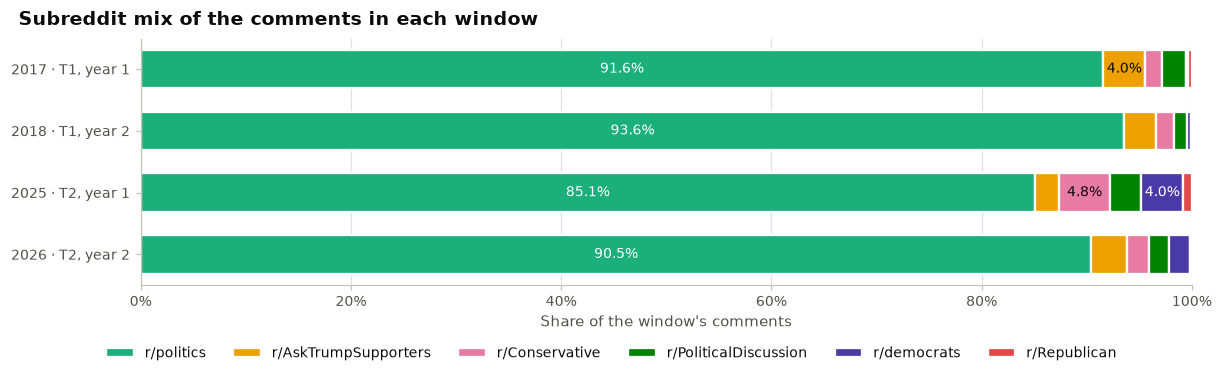

In [16]:
mix = 100 * pd.crosstab(com["period"], com["subreddit"], normalize="index").reindex(index=PERIODS, columns=SUBREDDITS)
rows = [PERIOD_SHORT[p].replace("\n", " · ") for p in PERIODS]

fig, ax = plt.subplots(figsize=(11, 3.3), layout="constrained")
left = np.zeros(len(PERIODS))
for s in SUBREDDITS:
    bars = ax.barh(rows, mix[s].values, left=left, height=0.62, color=SUB_COLOR[s], edgecolor="white", linewidth=1.5, label=f"r/{s}")
    for rect, v in zip(bars, mix[s].values):
        if v >= 3.5:
            ax.text(rect.get_x() + rect.get_width() / 2, rect.get_y() + rect.get_height() / 2, f"{v:.1f}%",
                    ha="center", va="center", fontsize=9, color=ink_on(SUB_COLOR[s]))
    left += mix[s].values
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(PERCENT)
ax.set_xlabel("Share of the window's comments")
ax.grid(axis="y", visible=False)
fig.legend(loc="outside lower center", ncols=6)
headline(fig, "Subreddit mix of the comments in each window")
plt.show()

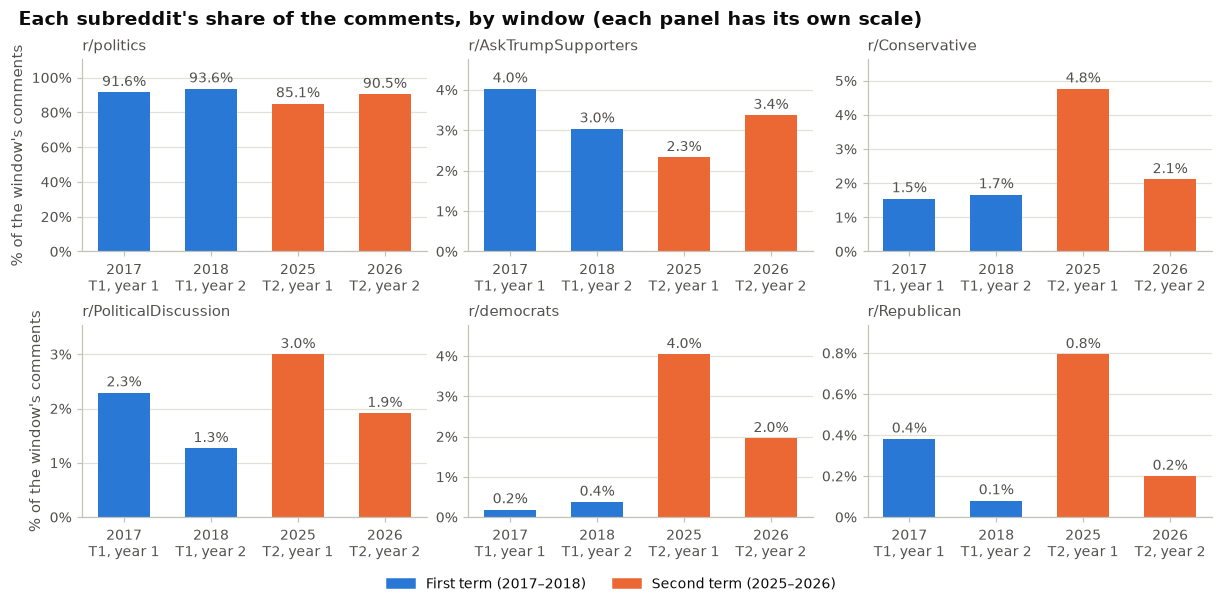

period,T1_Y1,T1_Y2,T2_Y1,T2_Y2,All
subreddit,,,,,
politics,"1,577,716","1,278,934","726,710","516,287","4,099,647"
AskTrumpSupporters,"69,382","41,510","19,896","19,247","150,035"
Conservative,"26,688","22,772","40,687","12,034","102,181"
PoliticalDiscussion,"39,499","17,312","25,598","10,926","93,335"
democrats,"3,231","5,103","34,493","11,160","53,987"
Republican,"6,574","1,101","6,778","1,142","15,595"
All,"1,723,090","1,366,732","854,162","570,796","4,514,780"


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(11, 5.4), layout="constrained")
for ax, s in zip(axes.flat, SUBREDDITS):
    bars = ax.bar([PERIOD_SHORT[p] for p in PERIODS], mix[s].values, width=0.6, color=[PERIOD_COLOR[p] for p in PERIODS])
    ax.bar_label(bars, fmt="%.1f%%", padding=2, fontsize=9, color=INK_2)
    ax.set_title(f"r/{s}")
    ax.set_ylim(0, mix[s].max() * 1.18)
    ax.yaxis.set_major_formatter(PERCENT)
    ax.grid(axis="x", visible=False)
for ax in axes[:, 0]:
    ax.set_ylabel("% of the window's comments")
fig.legend(handles=term_handles(), loc="outside lower center", ncols=2)
headline(fig, "Each subreddit's share of the comments, by window (each panel has its own scale)")
plt.show()

counts = pd.crosstab(com["subreddit"], com["period"], margins=True, margins_name="All").reindex(SUBREDDITS + ["All"])
with_commas(counts)

**What we see.**

- r/politics stays between 85% and 94% in every window, so pooled statistics describe r/politics.
- The first year of the second term is the most diverse window. r/politics drops to 85.1%, and r/Conservative (4.8%), r/democrats (4.0%) and r/PoliticalDiscussion (3.0%) reach their highest shares.
- r/democrats changes the most: from 3,231 comments in 2017 to 34,493 in 2025, more than ten times, while the dataset as a whole halved.
- r/Republican and r/Conservative have more comments in the first year of each term than in the second (see the table). Partisan communities seem to react most to the start of a term.

**What it means for the project.** The community mix is not constant, so a pooled change in tone between the terms can come from a change in who is represented. Comparisons of support and opposition must be made inside each subreddit, or weighted.

### 1.6 Who: authors

**Questions:** how many people write these comments, how unequal is their activity, and are the second-term authors the same people as in the first term?

Comments from deleted accounts (`[deleted]`) cannot be attributed to a person, so they are left out of this subsection.

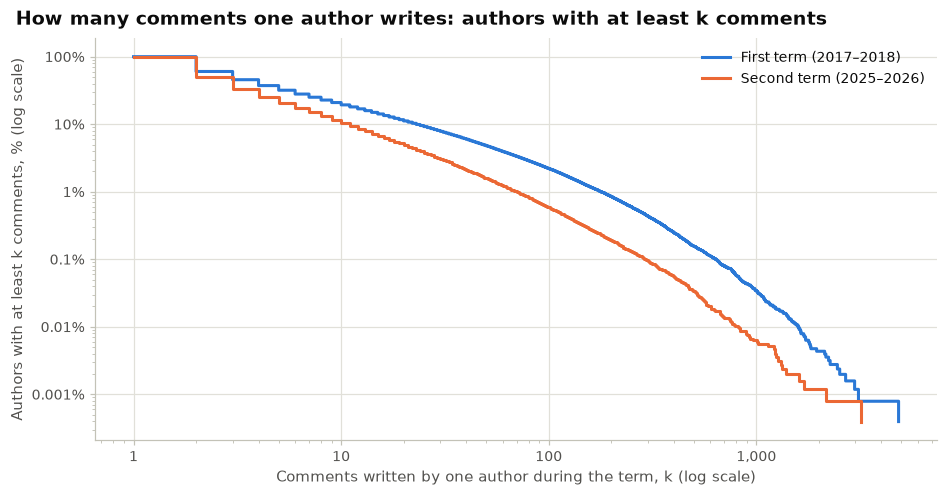

In [18]:
per_author = named.groupby(["term", "author"]).size()

fig, ax = plt.subplots(figsize=(8.5, 4.4), layout="constrained")
for term in TERMS:
    k, n_authors = np.unique(per_author[term].to_numpy(), return_counts=True)
    at_least_k = 100 * n_authors[::-1].cumsum()[::-1] / n_authors.sum()
    ax.plot(k, at_least_k, color=TERM_COLOR[term], drawstyle="steps-post", label=TERM_LABEL[term])
ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.yaxis.set_major_formatter(PERCENT)
ax.set_xlabel("Comments written by one author during the term, k (log scale)")
ax.set_ylabel("Authors with at least k comments, % (log scale)")
ax.legend()
headline(fig, "How many comments one author writes: authors with at least k comments")
plt.show()

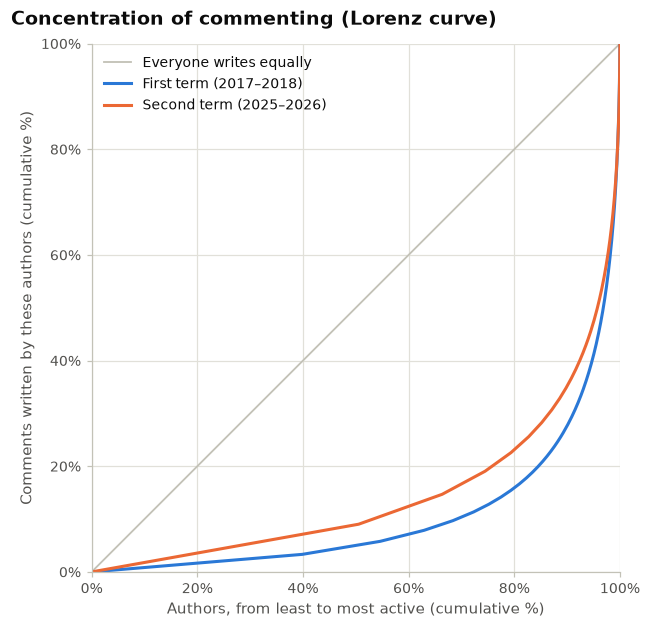

,First term (2017–2018),Second term (2025–2026)
authors,"253,172","254,072"
comments,"3,055,057","1,424,952"
median comments per author,2.0,1.0
mean comments per author,12.1,5.6
"most active author, comments","4,842","3,192"
"authors with exactly 1 comment, %",39.6,50.4
"comments written by the top 1% of authors, %",30.4,28.6
"comments written by the top 10% of authors, %",72.4,64.8
Gini coefficient,0.79,0.71


In [19]:
def concentration(counts):
    c = np.sort(counts)
    n, total = len(c), c.sum()
    gini = 2 * (np.arange(1, n + 1) * c).sum() / (n * total) - (n + 1) / n
    return {
        "authors": f"{n:,}",
        "comments": f"{total:,}",
        "median comments per author": np.median(c),
        "mean comments per author": round(c.mean(), 1),
        "most active author, comments": f"{c[-1]:,}",
        "authors with exactly 1 comment, %": round(100 * (c == 1).mean(), 1),
        "comments written by the top 1% of authors, %": round(100 * c[-max(1, n // 100):].sum() / total, 1),
        "comments written by the top 10% of authors, %": round(100 * c[-max(1, n // 10):].sum() / total, 1),
        "Gini coefficient": round(gini, 2),
    }


fig, ax = plt.subplots(figsize=(6.2, 5.6), layout="constrained")
ax.plot([0, 100], [0, 100], color=AXIS, linewidth=1.2, label="Everyone writes equally")
for term in TERMS:
    c = np.sort(per_author[term].to_numpy())
    ax.plot(np.linspace(0, 100, len(c) + 1), np.concatenate([[0], 100 * c.cumsum() / c.sum()]),
            color=TERM_COLOR[term], label=TERM_LABEL[term])
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_aspect("equal")
ax.xaxis.set_major_formatter(PERCENT)
ax.yaxis.set_major_formatter(PERCENT)
ax.set_xlabel("Authors, from least to most active (cumulative %)")
ax.set_ylabel("Comments written by these authors (cumulative %)")
ax.legend(loc="upper left")
headline(fig, "Concentration of commenting (Lorenz curve)")
plt.show()

pd.DataFrame({TERM_LABEL[t]: concentration(per_author[t].to_numpy()) for t in TERMS})

**What we see.**

- Both terms have almost the same number of authors, about 253,000 and 254,000, but the first term has twice as many comments (3.06M against 1.42M).
- Most authors write very little. Half of the second-term authors wrote exactly one comment that mentions Trump (40% in the first term). The median is 1–2 comments, the mean 6–12.
- A small core writes most of the text. The top 1% of authors wrote 30.4% of the comments in the first term and 28.6% in the second; the top 10% wrote 72.4% and 64.8%.
- The second term is less concentrated (Gini 0.71 against 0.79). On the log-log chart the second-term line lies below the first-term line everywhere: fewer heavy commenters at every level.

**What it means for the project.** Counting comments measures how loud a few thousand very active accounts are. To describe how many people support or oppose, we also need counts per unique author.

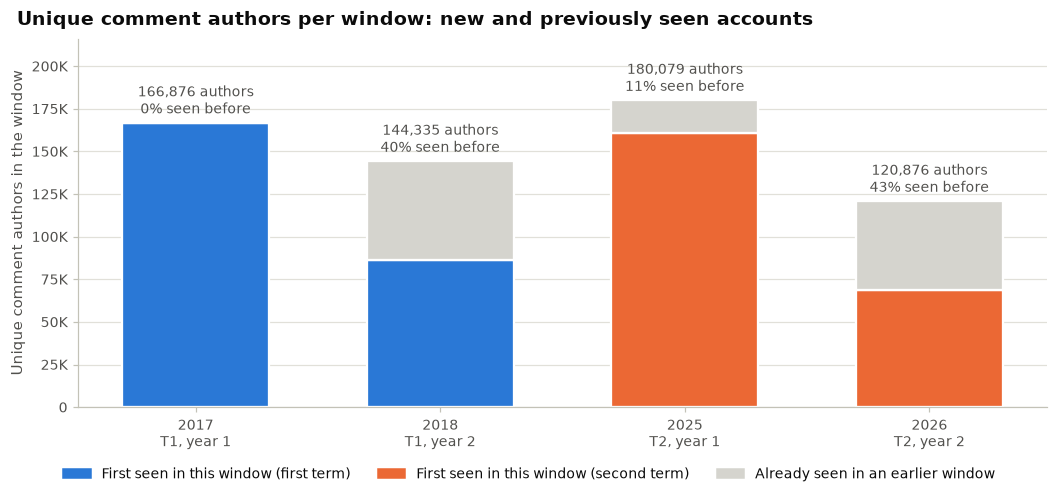

,value
authors active in the first term only,"228,396"
authors active in the second term only,"229,296"
authors active in both terms,"24,776"
share of second-term authors who also wrote in the first term,9.8%
share of second-term comments written by these authors,16.6%


In [20]:
# one row per author and year; the year stands for the window (2017, 2018, 2025, 2026)
author_year = named.groupby(["author", "year"]).size().reset_index(name="comments")
author_year["is_new"] = author_year["year"] == author_year.groupby("author")["year"].transform("min")

new_vs_seen = author_year.groupby("year")["is_new"].agg(new="sum", total="size").loc[list(PERIOD_YEAR.values())]
new_vs_seen["seen"] = new_vs_seen["total"] - new_vs_seen["new"]
labels = [PERIOD_SHORT[p] for p in PERIODS]

fig, ax = plt.subplots(figsize=(9.5, 4.4), layout="constrained")
ax.bar(labels, new_vs_seen["new"], width=0.6, color=[PERIOD_COLOR[p] for p in PERIODS], edgecolor="white", linewidth=1.5)
bars = ax.bar(labels, new_vs_seen["seen"], bottom=new_vs_seen["new"], width=0.6, color="#d5d4ce", edgecolor="white", linewidth=1.5)
ax.bar_label(bars, labels=[f"{t:,} authors\n{100 * s / t:.0f}% seen before" for s, t in zip(new_vs_seen["seen"], new_vs_seen["total"])],
             padding=3, fontsize=9, color=INK_2)
ax.set_ylim(0, new_vs_seen["total"].max() * 1.2)
ax.yaxis.set_major_formatter(COMPACT)
ax.set_ylabel("Unique comment authors in the window")
ax.grid(axis="x", visible=False)
fig.legend(handles=[Patch(color=TERM_COLOR["T1"], label="First seen in this window (first term)"),
                    Patch(color=TERM_COLOR["T2"], label="First seen in this window (second term)"),
                    Patch(color="#d5d4ce", label="Already seen in an earlier window")], loc="outside lower center", ncols=3)
headline(fig, "Unique comment authors per window: new and previously seen accounts")
plt.show()

terms_per_author = per_author.unstack("term").fillna(0)
both = (terms_per_author["T1"] > 0) & (terms_per_author["T2"] > 0)
pd.Series({
    "authors active in the first term only": f"{((terms_per_author['T1'] > 0) & ~both).sum():,}",
    "authors active in the second term only": f"{((terms_per_author['T2'] > 0) & ~both).sum():,}",
    "authors active in both terms": f"{both.sum():,}",
    "share of second-term authors who also wrote in the first term": f"{100 * both.sum() / (terms_per_author['T2'] > 0).sum():.1f}%",
    "share of second-term comments written by these authors": f"{100 * terms_per_author.loc[both, 'T2'].sum() / terms_per_author['T2'].sum():.1f}%",
}, name="value").to_frame()

**What we see.**

- Inside a term the audience carries over: 40% of the 2018 authors and 43% of the 2026 authors had already written in an earlier window.
- Across the seven-year gap it does not: only 11% of the 2025 authors appear in the first-term data.
- In total 24,776 accounts are active in both terms. They are 9.8% of the second-term authors and wrote 16.6% of the second-term comments.

**What it means for the project.** A comparison of the two terms is mostly a comparison of two different groups of people. The 24,776 returning authors are a natural panel for the question "did the same people change their tone?".

### 1.7 Thread structure

**Questions:** how much of a thread is about Trump, what do people link to, and are comments direct reactions to the post or replies to each other?

This is the only place where the two tables are merged. Each submission gets the number of its comments that are present in the comments table, joined on `comments.submission_id = submissions.id`. The join is one-to-one on the submission side, because the comments are counted per thread first. It lets us put two numbers side by side: `num_comments`, the size of the whole thread as Reddit reports it, and `trump_comments`, the number of comments in that thread that mention Trump.

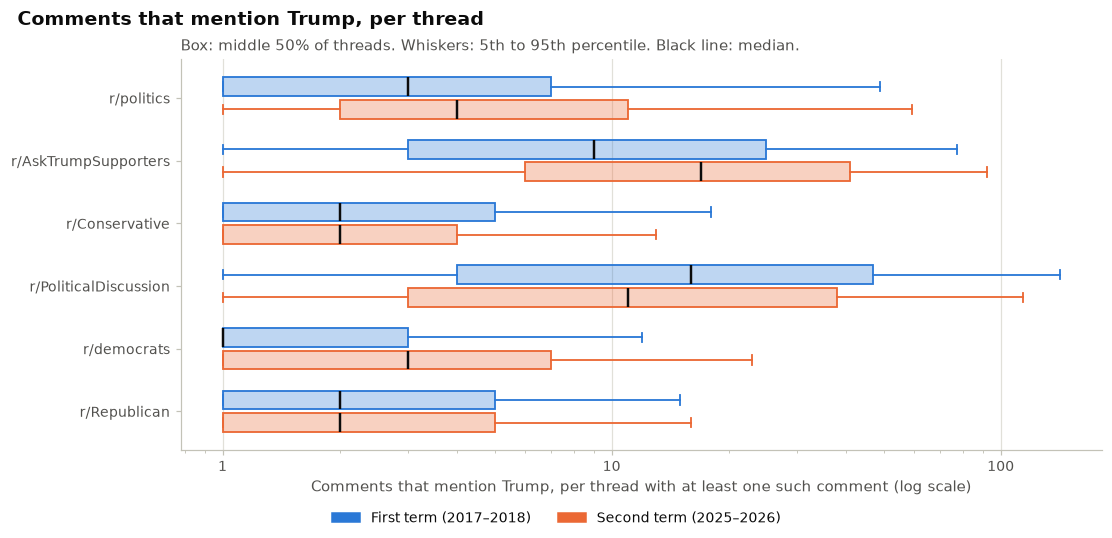

term,"median per thread, first term (2017–2018)","median per thread, second term (2025–2026)"
subreddit,,
r/politics,3,4
r/AskTrumpSupporters,9,17
r/Conservative,2,2
r/PoliticalDiscussion,16,11
r/democrats,1,3
r/Republican,2,2


,value
threads in the submissions table,"497,211"
threads with no comment that mentions Trump,34.9%
threads with exactly 1 such comment,18.6%
median such comments per thread (threads with at least 1),3
comments held by the 1% largest threads,32.6%


In [21]:
threads = subs.merge(comment_counts.rename("trump_comments"), left_on="id", right_index=True, how="left")
threads["trump_comments"] = threads["trump_comments"].fillna(0).astype("int32")
assert len(threads) == len(subs)


def term_boxes(ax, df, column, terms=TERMS):
    """One horizontal box per subreddit and term. Box = middle 50%, whiskers = 5th to 95th percentile, line = median."""
    groups = df.groupby(["subreddit", "term"])[column]
    for i, s in enumerate(SUBREDDITS):
        for j, term in enumerate(terms):
            if (s, term) not in groups.groups:
                continue
            position = i + (j - (len(terms) - 1) / 2) * 0.36
            color = TERM_COLOR[term]
            ax.boxplot(groups.get_group((s, term)).dropna().to_numpy(), positions=[position], orientation="horizontal",
                       whis=(5, 95), showfliers=False, patch_artist=True, widths=0.3, manage_ticks=False,
                       boxprops={"facecolor": mcolors.to_rgba(color, 0.30), "edgecolor": color, "linewidth": 1.2},
                       medianprops={"color": INK, "linewidth": 1.6},
                       whiskerprops={"color": color, "linewidth": 1.2}, capprops={"color": color, "linewidth": 1.2})
    ax.set_yticks(range(len(SUBREDDITS)), [f"r/{s}" for s in SUBREDDITS])
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)


with_comments = threads.loc[threads["trump_comments"] > 0]

fig, ax = plt.subplots(figsize=(10, 4.8), layout="constrained")
term_boxes(ax, with_comments, "trump_comments")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
ax.set_xlabel("Comments that mention Trump, per thread with at least one such comment (log scale)")
ax.set_title("Box: middle 50% of threads. Whiskers: 5th to 95th percentile. Black line: median.")
fig.legend(handles=term_handles(), loc="outside lower center", ncols=2)
headline(fig, "Comments that mention Trump, per thread")
plt.show()

display(with_comments.groupby(["subreddit", "term"])["trump_comments"].median().unstack("term").reindex(SUBREDDITS).astype(int)
        .rename(columns={t: f"median per thread, {TERM_LABEL[t].lower()}" for t in TERMS}).rename(index=lambda s: f"r/{s}"))

pd.Series({
    "threads in the submissions table": f"{len(threads):,}",
    "threads with no comment that mentions Trump": f"{100 * (threads['trump_comments'] == 0).mean():.1f}%",
    "threads with exactly 1 such comment": f"{100 * (threads['trump_comments'] == 1).mean():.1f}%",
    "median such comments per thread (threads with at least 1)": f"{with_comments['trump_comments'].median():.0f}",
    "comments held by the 1% largest threads": f"{100 * with_comments['trump_comments'].nlargest(len(with_comments) // 100).sum() / with_comments['trump_comments'].sum():.1f}%",
}, name="value").to_frame()

**What we see.**

- 34.9% of the threads have no comment that mentions Trump. They are in the dataset because the post itself does. Another 18.6% have exactly one such comment.
- Among threads with at least one such comment, the median is 3, and the 1% largest threads hold 32.6% of all comments. Megathreads dominate.
- The two discussion subreddits have much deeper threads. The median is 9–17 in r/AskTrumpSupporters and 11–16 in r/PoliticalDiscussion, against 2–4 in r/politics, r/Conservative and r/Republican.
- Between the terms the median rises in r/AskTrumpSupporters (9 to 17) and r/democrats (1 to 3), and falls in r/PoliticalDiscussion (16 to 11).

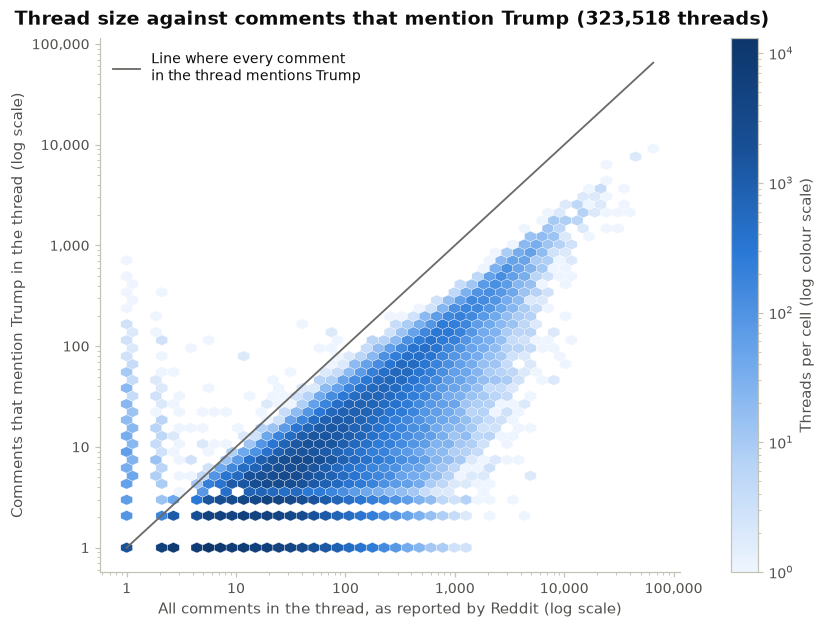

Spearman rank correlation: 0.76
Comments that mention Trump as a share of all comments in these threads: 13.3%
Threads with more Trump comments than Reddit's num_comments: 0.22%


In [22]:
both_positive = with_comments.loc[with_comments["num_comments"] > 0]
rank_correlation = both_positive["num_comments"].rank().corr(both_positive["trump_comments"].rank())

fig, ax = plt.subplots(figsize=(7.4, 5.6), layout="constrained")
hb = ax.hexbin(both_positive["num_comments"], both_positive["trump_comments"], xscale="log", yscale="log",
               gridsize=45, bins="log", mincnt=1, cmap=BLUES, linewidths=0.2, edgecolors="white")
limit = both_positive[["num_comments", "trump_comments"]].max().max()
ax.plot([1, limit], [1, limit], color=NEUTRAL, linewidth=1.2, label="Line where every comment\nin the thread mentions Trump")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_xlabel("All comments in the thread, as reported by Reddit (log scale)")
ax.set_ylabel("Comments that mention Trump in the thread (log scale)")
ax.grid(False)
fig.colorbar(hb, ax=ax, label="Threads per cell (log colour scale)")
headline(fig, f"Thread size against comments that mention Trump ({len(both_positive):,} threads)")
plt.show()

density = both_positive["trump_comments"].sum() / both_positive["num_comments"].sum()
print(f"Spearman rank correlation: {rank_correlation:.2f}")
print(f"Comments that mention Trump as a share of all comments in these threads: {100 * density:.1f}%")
print(f"Threads with more Trump comments than Reddit's num_comments: {100 * (both_positive['trump_comments'] > both_positive['num_comments']).mean():.2f}%")

**What we see.**

- Larger threads contain more comments that mention Trump. The rank correlation is 0.76.
- The cloud lies well below the diagonal. In these threads 13.3% of all comments mention Trump by name, so even in a thread about Trump most comments do not use the word.
- The horizontal bands at 1, 2 and 3 are threads of any size with only one to three such comments.
- A few threads (0.22%) lie above the diagonal, which is impossible in reality. The likely reason is that `num_comments` is a snapshot from the moment the post was archived, taken before the thread finished growing.

**What it means for the project.** The keyword filter keeps about one comment in eight from a Trump-related thread. Replies such as "he lied again" are missed. Our comments are the explicit mentions, not the whole conversation.

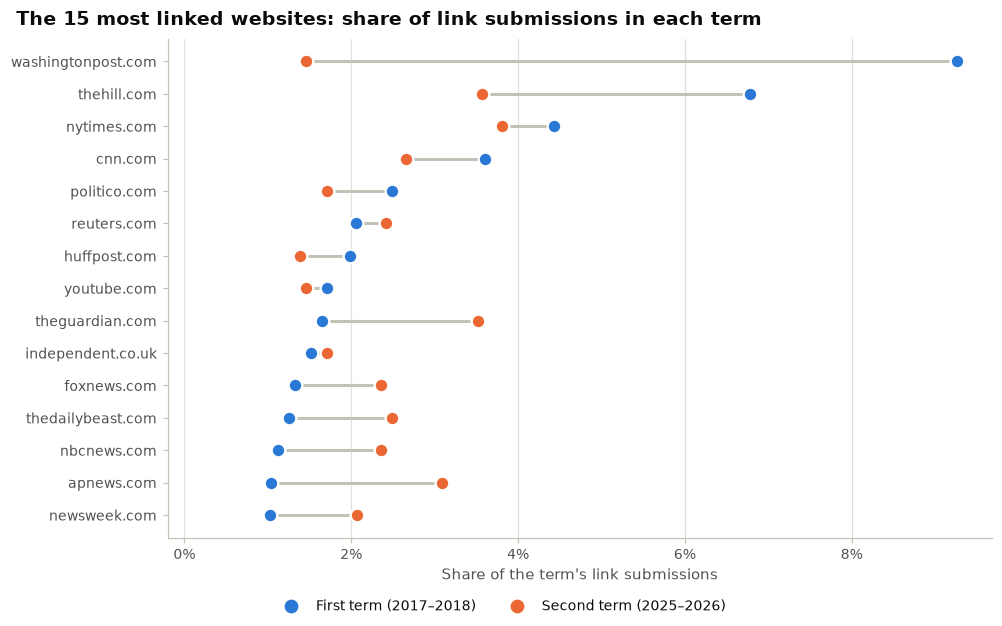

term,"% of links, first term (2017–2018)","% of links, second term (2025–2026)"
site,,
washingtonpost.com,9.3,1.5
thehill.com,6.8,3.6
nytimes.com,4.4,3.8
cnn.com,3.6,2.7
politico.com,2.5,1.7
reuters.com,2.1,2.4
huffpost.com,2.0,1.4
youtube.com,1.7,1.5
theguardian.com,1.7,3.5


link submissions: 464,390 (93.4% of all submissions), 11,693 different websites
share of link submissions that go to these 15 websites: First term (2017–2018) 41.3%, Second term (2025–2026) 36.1%


In [23]:
links = subs.loc[~subs["is_self"], ["term", "domain"]].copy()
links["site"] = (links["domain"].str.lower().str.replace(r"^(?:www|m|mobile|amp)\.", "", regex=True)
                 .replace({"huffingtonpost.com": "huffpost.com", "twitter.com": "x.com"}))    # sites that were renamed
site_share = 100 * pd.crosstab(links["site"], links["term"], normalize="columns")
top_sites = links["site"].value_counts().head(15).index
d = site_share.loc[top_sites].sort_values("T1", ascending=False)
y_pos = np.arange(len(d))

fig, ax = plt.subplots(figsize=(9, 5.6), layout="constrained")
ax.hlines(y_pos, d["T1"], d["T2"], color=AXIS, linewidth=2, zorder=1)
for term in TERMS:
    ax.scatter(d[term], y_pos, s=80, color=TERM_COLOR[term], edgecolor="white", linewidth=1.5, zorder=2)
ax.set_yticks(y_pos, d.index)
ax.invert_yaxis()
ax.set_xlim(-0.2, None)
ax.xaxis.set_major_formatter(PERCENT)
ax.set_xlabel("Share of the term's link submissions")
ax.grid(axis="y", visible=False)
fig.legend(handles=term_handles(marker="o"), loc="outside lower center", ncols=2)
headline(fig, "The 15 most linked websites: share of link submissions in each term")
plt.show()

display(d.round(1).rename(columns={t: f"% of links, {TERM_LABEL[t].lower()}" for t in TERMS}))
print(f"link submissions: {len(links):,} ({100 * len(links) / len(subs):.1f}% of all submissions), {links['site'].nunique():,} different websites")
print("share of link submissions that go to these 15 websites: "
      + ", ".join(f"{TERM_LABEL[t]} {site_share.loc[top_sites, t].sum():.1f}%" for t in TERMS))

**What we see.**

- 93.4% of submissions are links to other websites, so the submissions table mostly shows which news sources each community shares.
- The first term leaned on a few large outlets. The Washington Post alone was 9.3% of link submissions, The Hill 6.8%.
- In the second term these two fall to 1.5% and 3.6%. The Guardian, Fox News, The Daily Beast, NBC News and Newsweek roughly double their share, and AP News triples it (1.0% to 3.1%).
- The source mix is flatter: the top 15 websites cover 41% of first-term links and 36% of second-term links.

The fall of The Washington Post is the largest single change. A possible reason is its paywall and the rules of r/politics, but the data cannot confirm this.

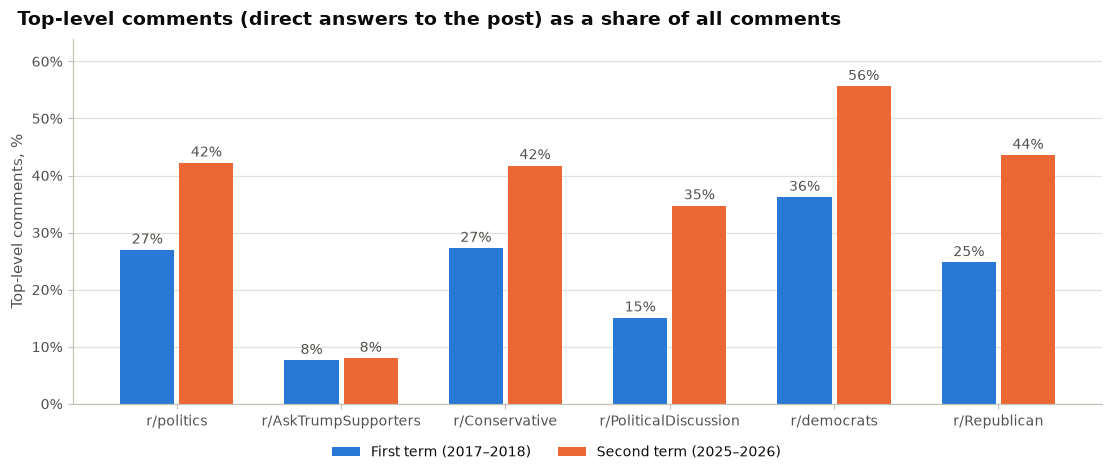

In [24]:
top_level = 100 * com.groupby(["subreddit", "term"])["is_top_level"].mean().unstack("term").reindex(SUBREDDITS)
x_pos = np.arange(len(SUBREDDITS))

fig, ax = plt.subplots(figsize=(10, 4.2), layout="constrained")
for j, term in enumerate(TERMS):
    bars = ax.bar(x_pos + (j - 0.5) * 0.36, top_level[term], width=0.33, color=TERM_COLOR[term], label=TERM_LABEL[term])
    ax.bar_label(bars, fmt="%.0f%%", padding=2, fontsize=9, color=INK_2)
ax.set_xticks(x_pos, [f"r/{s}" for s in SUBREDDITS])
ax.set_ylim(0, top_level.max().max() * 1.15)
ax.yaxis.set_major_formatter(PERCENT)
ax.set_ylabel("Top-level comments, %")
ax.grid(axis="x", visible=False)
fig.legend(loc="outside lower center", ncols=2)
headline(fig, "Top-level comments (direct answers to the post) as a share of all comments")
plt.show()

**What we see.**

- Outside r/AskTrumpSupporters, 15–36% of first-term comments were top-level, depending on the subreddit. In the second term it is 35–56%. The share rises by 15–20 points in each of these five subreddits.
- r/AskTrumpSupporters stays at 8% in both terms. Its format is a question followed by long reply chains, and it did not change.

A higher top-level share means fewer replies between users and more separate reactions to the post. This fits the earlier finding that second-term authors write fewer comments each. We do not see how the change of archive could produce this difference, but we have not ruled it out.

### 1.8 Reception: scores and controversy

**Questions:** how are comments that mention Trump received, and does the reception differ between terms and communities?

`score` is upvotes minus downvotes; a new comment starts at 1. `controversiality` is Reddit's own flag for comments with many votes in both directions. `upvote_ratio` exists only for the second term, so it is shown for the second term only.

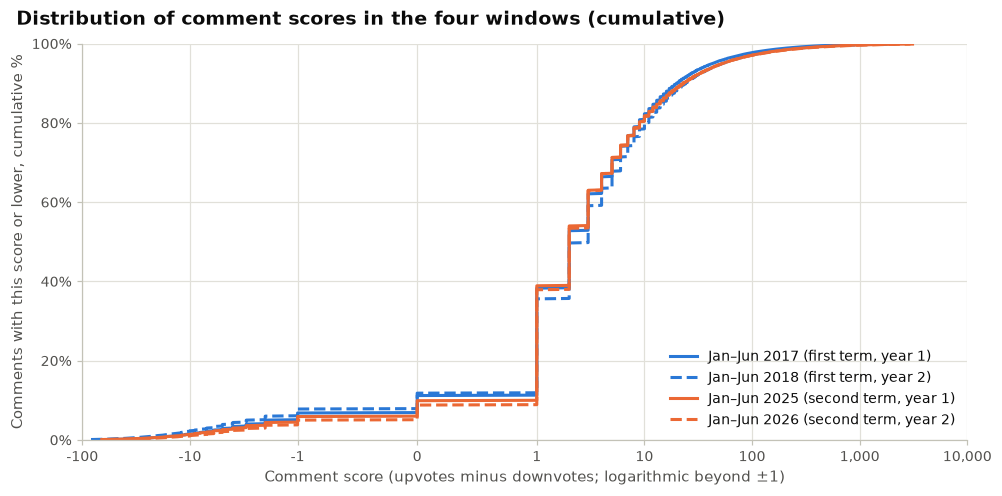

,mean,min,5%,25%,50%,75%,95%,99%,max,"score below 1, %","score exactly 1, %"
period,,,,,,,,,,,
T1_Y1,16.0,-580.0,-2.0,1.0,2.0,7.0,43.0,233.0,19979.0,11.3,27.1
T1_Y2,19.9,-1375.0,-3.0,1.0,3.0,8.0,53.0,307.0,33293.0,11.8,23.8
T2_Y1,22.8,-1129.0,-1.0,1.0,2.0,7.0,53.0,329.0,26449.0,10.0,29.0
T2_Y2,23.9,-586.0,-1.0,1.0,2.0,7.0,53.0,352.1,28194.0,8.8,29.1


In [25]:
quantiles = np.linspace(0.001, 0.999, 999)

fig, ax = plt.subplots(figsize=(9, 4.4), layout="constrained")
for p in PERIODS:
    scores = com.loc[com["period"] == p, "score"].to_numpy()
    ax.plot(np.quantile(scores, quantiles), 100 * quantiles, color=PERIOD_COLOR[p], linestyle=PERIOD_LINESTYLE[p], label=PERIOD_LONG[p])
ax.set_xscale("symlog", linthresh=1)
ax.set_xlim(-100, 10_000)
ax.set_xticks([-100, -10, -1, 0, 1, 10, 100, 1_000, 10_000], ["-100", "-10", "-1", "0", "1", "10", "100", "1,000", "10,000"])
ax.minorticks_off()
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PERCENT)
ax.set_xlabel("Comment score (upvotes minus downvotes; logarithmic beyond ±1)")
ax.set_ylabel("Comments with this score or lower, cumulative %")
ax.legend(loc="lower right")
headline(fig, "Distribution of comment scores in the four windows (cumulative)")
plt.show()

score_table = com.groupby("period")["score"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).drop(columns=["count", "std"]).round(1)
score_table["score below 1, %"] = (100 * com.assign(low=com["score"] < 1).groupby("period")["low"].mean()).round(1)
score_table["score exactly 1, %"] = (100 * com.assign(one=com["score"] == 1).groupby("period")["one"].mean()).round(1)
score_table

**What we see.**

- The four curves almost coincide. The way comments are rewarded did not change between the terms.
- Most comments get little attention: 24–29% keep the starting score of 1, and the median is 2–3.
- 9–12% of comments are voted below 1. This share is slightly lower in the second term (8.8% in 2026 against 11.3% in 2017).
- The tail is long. The 95th percentile is 43–53, the 99th is 233–352, and the maximum is above 19,000 in every window. The mean (16–24) is far from the median, so means are a poor summary here.

**Caution.** First-term scores are three to five weeks old and second-term scores 1.5 days old (section 1.3). The near-identical curves suggest that most votes arrive within the first day, but small differences between terms should not be read as real.

**What it means for the project.** The score is how the community reacts to a comment. In a subreddit with a clear majority, the score can be used later as a signal of which stance that community rewards.

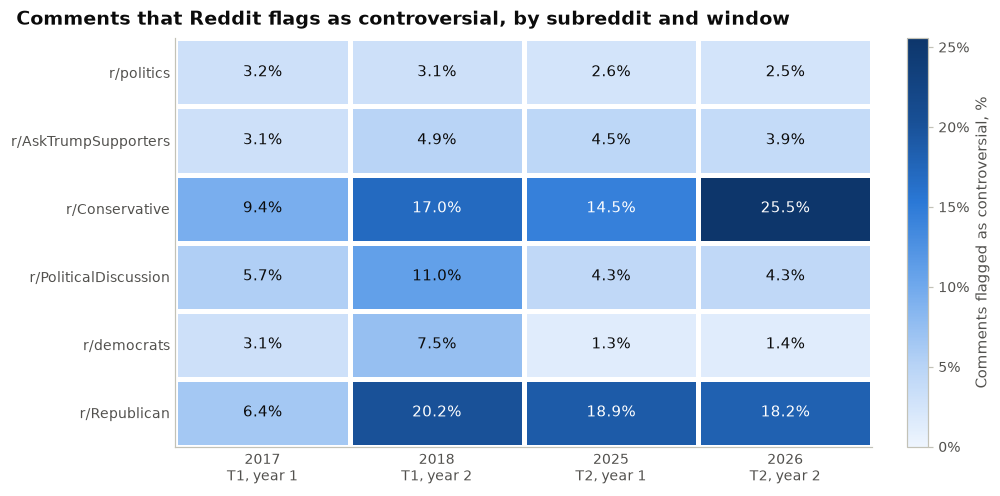

In [26]:
controversial = 100 * com.groupby(["subreddit", "period"])["controversiality"].mean().unstack("period").reindex(index=SUBREDDITS, columns=PERIODS)

fig, ax = plt.subplots(figsize=(9, 4.4), layout="constrained")
mesh = ax.pcolormesh(controversial.to_numpy(), cmap=BLUES, vmin=0, edgecolors="white", linewidth=2)
for i in range(controversial.shape[0]):
    for j in range(controversial.shape[1]):
        v = controversial.iat[i, j]
        ax.text(j + 0.5, i + 0.5, f"{v:.1f}%", ha="center", va="center", fontsize=9.5, color=ink_on(mesh.cmap(mesh.norm(v))))
ax.set_xticks(np.arange(len(PERIODS)) + 0.5, [PERIOD_SHORT[p] for p in PERIODS])
ax.set_yticks(np.arange(len(SUBREDDITS)) + 0.5, [f"r/{s}" for s in SUBREDDITS])
ax.invert_yaxis()
ax.grid(False)
ax.tick_params(length=0)
fig.colorbar(mesh, ax=ax, label="Comments flagged as controversial, %", format=PERCENT)
headline(fig, "Comments that Reddit flags as controversial, by subreddit and window")
plt.show()

**What we see.**

- Controversy is concentrated in the right-leaning communities. In r/Conservative 9.4% of comments were controversial in 2017 and 25.5% in 2026. In r/Republican the share is 18–20% from 2018 onward.
- r/politics is stable and low, 2.5–3.2%.
- r/democrats is the least contested in the second term (1.3–1.4%).
- 2018 is more contested than 2017 in every subreddit except r/politics.

**What it means for the project.** In r/Conservative one comment in four that mentions Trump now splits the voters. This can be a real disagreement among conservatives about Trump, or outside users voting in the subreddit. It is one of the most direct signs of contested opinion in the dataset, and we return to it with text analysis.

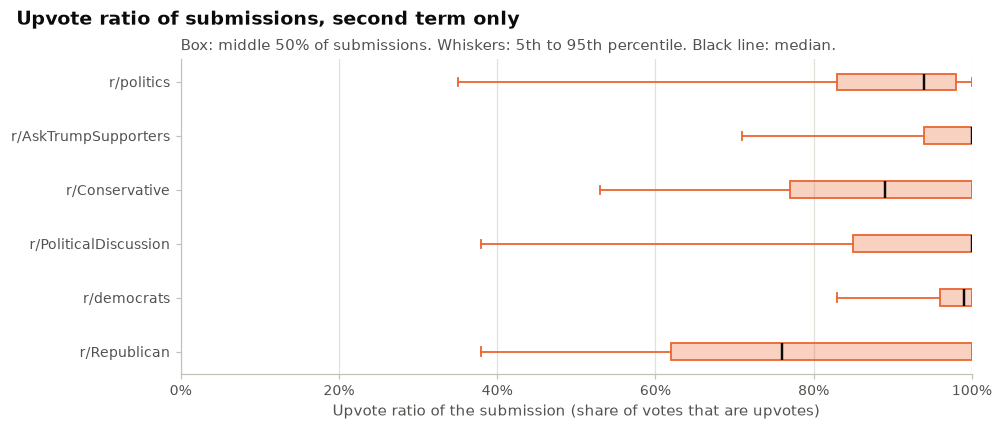

,count,mean,5%,25%,50%,75%
subreddit,,,,,,
politics,106993.0,86.0,35.0,83.0,94.0,98.0
AskTrumpSupporters,4922.0,94.8,71.0,94.0,100.0,100.0
Conservative,25921.0,85.7,53.0,77.0,89.0,100.0
PoliticalDiscussion,3535.0,88.9,38.0,85.0,100.0,100.0
democrats,10070.0,96.1,83.0,96.0,99.0,100.0
Republican,3399.0,75.9,38.0,62.0,76.0,100.0


In [27]:
rated = subs.loc[subs["upvote_ratio"].notna()].assign(upvote_pct=lambda d: 100 * d["upvote_ratio"])

fig, ax = plt.subplots(figsize=(9, 3.8), layout="constrained")
term_boxes(ax, rated, "upvote_pct", terms=["T2"])
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(PERCENT)
ax.set_xlabel("Upvote ratio of the submission (share of votes that are upvotes)")
ax.set_title("Box: middle 50% of submissions. Whiskers: 5th to 95th percentile. Black line: median.")
headline(fig, "Upvote ratio of submissions, second term only")
plt.show()

rated.groupby("subreddit")["upvote_pct"].describe(percentiles=[0.05, 0.25, 0.5, 0.75]).drop(columns=["std", "min", "max"]).reindex(SUBREDDITS).round(1)

**What we see.**

- r/democrats is the most uniform: half of its submissions have an upvote ratio of 99% or more, and 95% of them are above 83%.
- r/Republican is the most split, with a median of 76% and a quarter of submissions below 62%.
- r/Conservative sits in between (median 89%). r/politics has a high median (94%) but a long lower tail.

This agrees with the controversy chart: posts about Trump are received with the least agreement in the right-leaning subreddits. The field does not exist for the first term, so we cannot say whether this is new.

### 1.9 Text length

**Question:** how long are the comments, and are some communities or terms wordier?

Length is counted on `body_clean`, the comment text without quoted lines and links, as the number of whitespace-separated words.

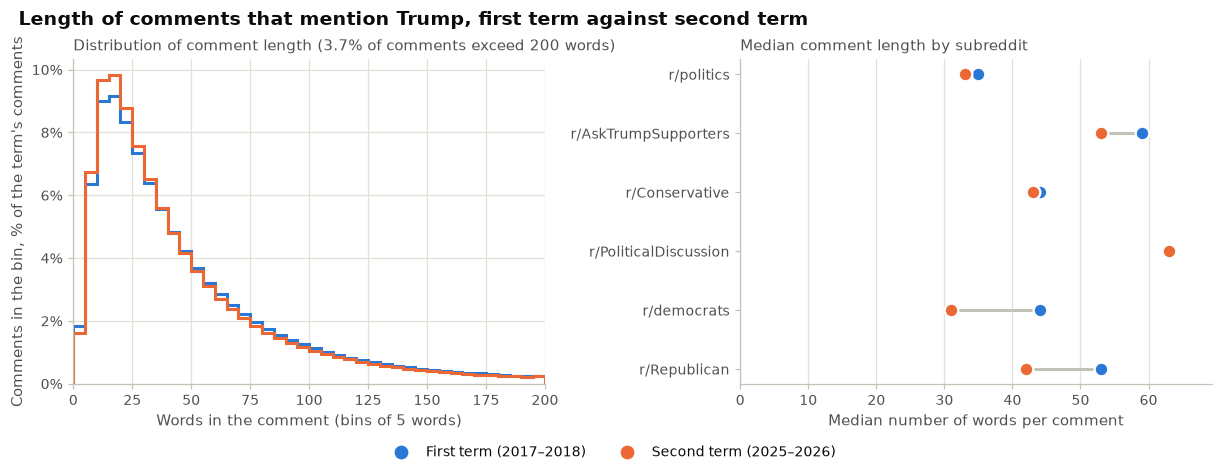

,mean,min,25%,50%,75%,95%,99%,max,"up to 10 words, %"
period,,,,,,,,,
T1_Y1,58.7,1.0,19.0,37.0,70.0,179.0,351.0,4926.0,9.4
T1_Y2,56.3,1.0,18.0,35.0,67.0,172.0,342.0,5601.0,10.5
T2_Y1,56.2,1.0,18.0,35.0,66.0,173.0,343.0,1744.0,9.8
T2_Y2,54.4,1.0,17.0,33.0,63.0,167.0,352.0,1650.0,10.7


In [28]:
edges = np.arange(0, 205, 5)
median_words = com.groupby(["subreddit", "term"])["n_words"].median().unstack("term").reindex(SUBREDDITS)
y_pos = np.arange(len(SUBREDDITS))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), layout="constrained")

ax = axes[0]
for term in TERMS:
    words = com.loc[com["term"] == term, "n_words"].to_numpy()
    share, _ = np.histogram(words, bins=edges)
    ax.stairs(100 * share / len(words), edges, color=TERM_COLOR[term], linewidth=2, label=TERM_LABEL[term])
ax.set_xlim(0, 200)
ax.set_ylim(0, None)
ax.yaxis.set_major_formatter(PERCENT)
ax.set_xlabel("Words in the comment (bins of 5 words)")
ax.set_ylabel("Comments in the bin, % of the term's comments")
ax.set_title(f"Distribution of comment length ({100 * (com['n_words'] > 200).mean():.1f}% of comments exceed 200 words)")

ax = axes[1]
ax.hlines(y_pos, median_words["T1"], median_words["T2"], color=AXIS, linewidth=2, zorder=1)
for term in TERMS:
    ax.scatter(median_words[term], y_pos, s=80, color=TERM_COLOR[term], edgecolor="white", linewidth=1.5, zorder=2)
ax.set_yticks(y_pos, [f"r/{s}" for s in SUBREDDITS])
ax.invert_yaxis()
ax.set_xlim(0, median_words.max().max() * 1.1)
ax.set_xlabel("Median number of words per comment")
ax.set_title("Median comment length by subreddit")
ax.grid(axis="y", visible=False)

fig.legend(handles=term_handles(marker="o"), loc="outside lower center", ncols=2)
headline(fig, "Length of comments that mention Trump, first term against second term")
plt.show()

length_table = com.groupby("period")["n_words"].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]).drop(columns=["count", "std"]).round(1)
length_table["up to 10 words, %"] = (100 * com.assign(short=com["n_words"] <= 10).groupby("period")["short"].mean()).round(1)
length_table

In [29]:
median_words.astype(int).rename(columns={t: f"median words, {TERM_LABEL[t].lower()}" for t in TERMS}).rename(index=lambda s: f"r/{s}")

term,"median words, first term (2017–2018)","median words, second term (2025–2026)"
subreddit,,
r/politics,35,33
r/AskTrumpSupporters,59,53
r/Conservative,44,43
r/PoliticalDiscussion,63,63
r/democrats,44,31
r/Republican,53,42


**What we see.**

- A typical comment is short: the median is 33–37 words. One comment in ten has 10 words or fewer, and 3.7% are longer than 200 words.
- The two terms have almost the same distribution. The median falls slowly from 37 words in 2017 to 33 in 2026.
- Length depends on the community much more than on the term. The discussion subreddits are the wordiest (r/PoliticalDiscussion 63 words in both terms, r/AskTrumpSupporters 59 and 53). r/politics is the shortest (35 and 33).
- Comments became shorter in r/democrats (44 to 31 words) and r/Republican (53 to 42).

**What it means for the project.** Most comments are long enough for sentiment or stance classification, but the 10% of very short ones will be hard to classify.

### 1.10 When people post

**Question:** at what hours and on which weekdays are comments written, and is the weekly rhythm the same in both terms?

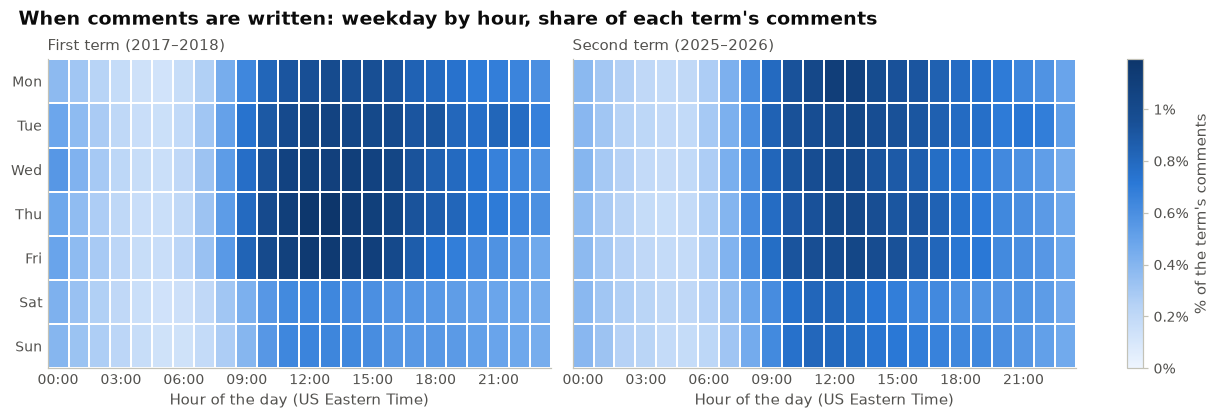

,"written on Sat–Sun, %","written 00:00–05:59 ET, %"
term,,
T1,20.8,11.2
T2,25.0,10.6


In [30]:
hourly = com.groupby(["term", "weekday_et", "hour_et"]).size()
grids = {}
for term in TERMS:
    g = hourly[term].unstack("hour_et").reindex(index=range(7), columns=range(24), fill_value=0)
    grids[term] = 100 * g / g.to_numpy().sum()
vmax = max(g.to_numpy().max() for g in grids.values())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.7), sharey=True, layout="constrained")
for ax, term in zip(axes, TERMS):
    mesh = ax.pcolormesh(grids[term].to_numpy(), cmap=BLUES, vmin=0, vmax=vmax, edgecolors="white", linewidth=1)
    ax.set_xticks(np.arange(0, 24, 3) + 0.5, [f"{h:02d}:00" for h in range(0, 24, 3)])
    ax.set_xlabel("Hour of the day (US Eastern Time)")
    ax.set_title(TERM_LABEL[term])
    ax.grid(False)
    ax.tick_params(length=0)
axes[0].set_yticks(np.arange(7) + 0.5, WEEKDAYS)
axes[0].invert_yaxis()
fig.colorbar(mesh, ax=axes, label="% of the term's comments", format=PERCENT)
headline(fig, "When comments are written: weekday by hour, share of each term's comments")
plt.show()

weekend = com.assign(weekend=com["weekday_et"] >= 5, night=com["hour_et"] < 6).groupby("term")[["weekend", "night"]].mean()
(100 * weekend).round(1).rename(columns={"weekend": "written on Sat–Sun, %", "night": "written 00:00–05:59 ET, %"})

**What we see.**

- Activity follows the American working day. It rises at 08:00, peaks between 10:00 and 15:00 Eastern Time on weekdays, and is lowest between 03:00 and 06:00.
- Weekends are quieter. They hold 20.8% of first-term comments and 25.0% of second-term comments; an even spread would give 28.6%.
- The weekend share grew in the second term, and it is 25.0% in both of its windows. The two Saturday events of 2026 (section 1.4) explain only 0.7 points of this; without them the share is 24.3%. The shift is general, not event-driven.

Discussion of Trump on Reddit is a daytime, weekday activity that follows the news cycle, in both terms.

### 1.11 Declared stance in r/AskTrumpSupporters

**Question:** who speaks in the one community where every author declares a side, and does the balance between supporters and nonsupporters move between the terms?

The stance is counted twice: per comment (how much each side says) and per unique author (how many people are on each side). An author who changed flair inside a window is counted once for each flair.

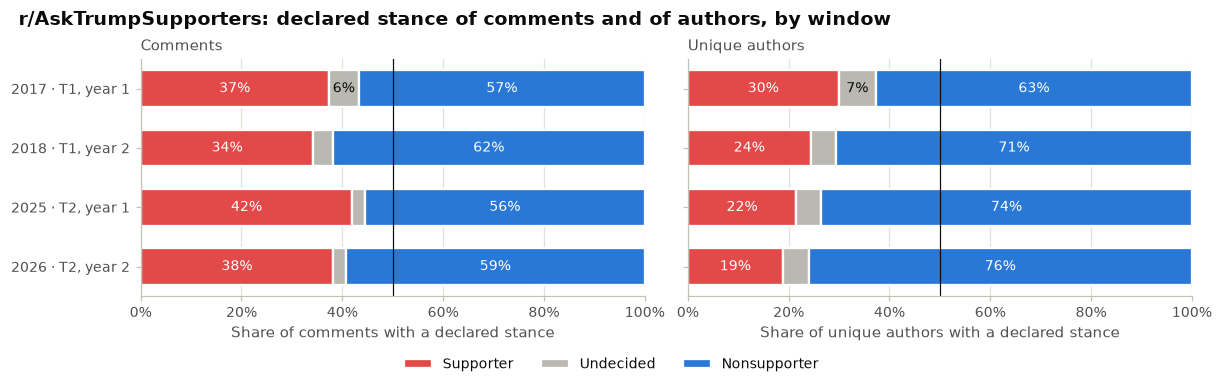

comments                                      unique authors                                     
stance            nonsupporter other / no flair supporter undecided   nonsupporter other / no flair supporter undecided
2017 · T1, year 1       35,888            6,072    23,591     3,831          3,201            1,333     1,528       379
2018 · T1, year 2       25,356              536    14,036     1,582          2,097               14       724       150
2025 · T2, year 1       11,019               45     8,332       500          1,939               44       567       130
2026 · T2, year 2       11,375               66     7,323       483          1,446               53       358        98

In [31]:
ats = com.loc[com["subreddit"] == "AskTrumpSupporters", ["period", "author", "author_deleted", "stance"]].copy()
ats["stance"] = ats["stance"].where(ats["stance"].isin(STANCES), "other / no flair")

stance_comments = pd.crosstab(ats["period"], ats["stance"]).reindex(PERIODS)
ats_authors = ats.loc[~ats["author_deleted"], ["period", "author", "stance"]].drop_duplicates()
stance_authors = pd.crosstab(ats_authors["period"], ats_authors["stance"]).reindex(PERIODS)
rows = [PERIOD_SHORT[p].replace("\n", " · ") for p in PERIODS]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True, layout="constrained")
for ax, (label, table) in zip(axes, {"Comments": stance_comments, "Unique authors": stance_authors}.items()):
    share = 100 * table[STANCES].div(table[STANCES].sum(axis=1), axis=0)
    left = np.zeros(len(PERIODS))
    for stance in STANCES:
        bars = ax.barh(rows, share[stance].values, left=left, height=0.62, color=STANCE_COLOR[stance],
                       edgecolor="white", linewidth=1.5, label=stance.capitalize())
        for rect, v in zip(bars, share[stance].values):
            if v >= 6:
                ax.text(rect.get_x() + rect.get_width() / 2, rect.get_y() + rect.get_height() / 2, f"{v:.0f}%",
                        ha="center", va="center", fontsize=9, color=ink_on(STANCE_COLOR[stance]))
        left += share[stance].values
    ax.axvline(50, color=INK, linewidth=0.8)
    ax.set_xlim(0, 100)
    ax.xaxis.set_major_formatter(PERCENT)
    ax.set_xlabel(f"Share of {label.lower()} with a declared stance")
    ax.set_title(label)
    ax.grid(axis="y", visible=False)
axes[0].invert_yaxis()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=3)
headline(fig, "r/AskTrumpSupporters: declared stance of comments and of authors, by window")
plt.show()

stance_table = pd.concat({"comments": stance_comments, "unique authors": stance_authors}, axis=1)
stance_table.index = [PERIOD_SHORT[p].replace("\n", " · ") for p in PERIODS]
with_commas(stance_table)

In [32]:
per_stance = (stance_comments[STANCES] / stance_authors[STANCES]).round(1)
per_stance.index = [PERIOD_SHORT[p].replace("\n", " · ") for p in PERIODS]
per_stance.columns = [f"comments per {s} author" for s in STANCES]
per_stance

,comments per supporter author,comments per undecided author,comments per nonsupporter author
"2017 · T1, year 1",15.4,10.1,11.2
"2018 · T1, year 2",19.4,10.5,12.1
"2025 · T2, year 1",14.7,3.8,5.7
"2026 · T2, year 2",20.5,4.9,7.9


**What we see.**

- Nonsupporters are the majority in both counts and in every window.
- By comments the balance is stable: supporters write 34–42% of the comments and nonsupporters 56–62%.
- By people it is not stable. Supporters fall from 30% of the authors in 2017 to 19% in 2026, and from 1,528 accounts to 358.
- The two views differ because supporters write much more. A supporter wrote 15–21 comments per window in every window. A nonsupporter wrote 11–12 in the first term and 6–8 in the second.
- The subreddit itself shrank, from 69,382 comments in 2017 to 19,247 in 2026.
- In 2017, 6,072 comments (8.8%) had no usable flair. After 2017 almost every comment has one.

**What it means for the project.** A shrinking group of supporters keeps the supporter share of comments constant by writing more. The share of supportive comments and the share of supportive people are different measures and can move in opposite directions, so we report both. The format of this subreddit also matters: supporters answer and nonsupporters ask, so its balance cannot be generalised to Reddit.

### 1.12 What we learned and what we ask next

**Main findings of the basic exploration**

1. The dataset is large and clean: 4.5M comments and 0.5M submissions, no duplicates, no gaps in the core fields.
2. Volume halves from the first term to the second, while the number of authors stays the same. Second-term authors write less each and reply to each other less.
3. Both terms have the same rhythm: a strong first year that decays, and a flat second year. Peaks follow news events, and the events differ: investigations and institutions in the first term, foreign policy and the reshaping of government in the second.
4. r/politics is 85–94% of every window. The other communities change a lot, above all r/democrats (ten times more comments in 2025 than in 2017).
5. Only 10% of second-term authors were active in the first term. The two terms are mostly two different audiences.
6. Trump-related comments are far more contested in right-leaning subreddits, and increasingly so: a quarter of such comments in r/Conservative were controversial in 2026.
7. In r/AskTrumpSupporters the supporters are a shrinking minority of people but a stable share of comments.

**Limits to keep in mind**

- Counts are not shares of all Reddit activity, because the data was filtered by keyword before we received it.
- The two terms were archived differently: weeks after posting in the first term, 1.5 days after in the second. Edits, deletions, removals and scores are not fully comparable across terms.
- The filter catches only the word "Trump". About one comment in eight in a Trump-related thread uses it.

**Questions and hypotheses for the next sections**

1. Is the tone of comments about Trump more negative in the second term than in the first, inside the same subreddit?
2. Does support fade from the first to the second year of a term, in both terms (a "honeymoon" effect)?
3. Do the peak events change the balance between supportive and hostile comments, or only the volume?
4. Is the growing controversy in r/Conservative and r/Republican a disagreement among conservatives about Trump? Do controversial comments there criticise him or defend him?
5. Do declared supporters and nonsupporters in r/AskTrumpSupporters use different words? Can their flairs serve as labels for a stance classifier for the other subreddits?
6. Did the 24,776 authors who wrote in both terms change their tone?
7. Which policy topics (Russia, immigration, tariffs, Ukraine, Iran, DOGE) attract support and which attract hostility, and how does the topic mix differ between the terms?
8. Do communities reward one stance with higher scores, and did this change between the terms?
9. Do threads that link to different news sources differ in tone?
10. Are supporters or opponents more concentrated, with a few very active authors producing most of the text?